# Synthetic Datasets: Plots of Utility and Group Fairness Metrics

Author: Ilse Harmers \
Last modified: April 8, 2026

In [1]:
# Importing libraries.
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
from matplotlib import ticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

import matplotlib
params = {'axes.titlesize':'20',
          'xtick.labelsize':'18',
          'ytick.labelsize':'18',
          'font.size':'18',
          'legend.fontsize':'medium',
          'lines.linewidth':'2.0',
          'font.weight':'normal',
          'lines.markersize':'5',
          'text.latex.preamble': r'\usepackage{amsfonts}',
          }
matplotlib.rcParams.update(params)
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

## Initialization

In [2]:
# Initializing the values for epsilon, the labels for the different metrics, the weights used in the guidelines and our functions. 
epsi = [1, 2, 5, 8]
metrics = ["acc", "prec", "recall", "auroc", "dem", "dis", "eqopp"]
weights = [1, 1, 0]   # 1: auroc; 1: group fairness; 0: privacy

def synth_selection(models, epsilon, dataset, weights = [1, 1, 1]):
    """This function returns the rankings of the 'best' synthetic datasets out of all our models for an epsilon 'epsilon'. 'Best' refers to the 
    datasets which are best able to balance classifier utility (AUROC), classifier group fairness (demographic parity, disparate impact and equal 
    opportunity) and privacy (DCR and NNDR). The rankings are based on a point-based ranking scheme where the 'best' results for each of the metrics 
    are ranked from first through last place. This function also returns the (un)processed utility and fairness results and the privacy results
    of the synthetic datasets. 

    The total number of synthetic datasets for each model is hard-coded as 15, which should be modified in cases where this is not true.
    
    models [list]: folder locations of the GANs' synthetic datasets
    epsilon [integer]: epsilon value 
    dataset [string]: folder name of the synthetic datasets; can be set to "adult", "bank-marketing" or "credit-card-default"
    weights [list]: utility, fairness and privacy weights assigned to the AUROC, classifier group fairness and privacy points of the synthetic datasets
    """

    metrics = ["acc", "auroc", "dem", "dis", "eqopp"]
    results_eps_avg = {}
    results_eps_avg_std = {}
    privacy_results = {}
    
    for mod in models:
        if mod == "TabFair":
            file_path = f"./synthetic-datasets_{mod}/{dataset}/"

            # Importing synthetic datasets' results as pandas DataFrames.
            run1 = pd.read_csv(file_path + f"run1/results_run1.csv", index_col = 0, na_values = "np.nan")
            run2 = pd.read_csv(file_path + f"run2/results_run2.csv", index_col = 0, na_values = "np.nan")
            run3 = pd.read_csv(file_path + f"run3/results_run3.csv", index_col = 0, na_values = "np.nan")
            run4 = pd.read_csv(file_path + f"run4/results_run4.csv", index_col = 0, na_values = "np.nan")
            run5 = pd.read_csv(file_path + f"run5/results_run5.csv", index_col = 0, na_values = "np.nan")
        else:
            file_path = f"./synthetic-datasets_{mod}_B=512/{dataset}/"

            # Importing synthetic datasets' results as pandas DataFrames.
            run1 = pd.read_csv(file_path + f"epsi_{epsilon}/run1/results_epsi-{epsilon}_run1.csv", index_col = 0, na_values = "np.nan")
            run2 = pd.read_csv(file_path + f"epsi_{epsilon}/run2/results_epsi-{epsilon}_run2.csv", index_col = 0, na_values = "np.nan")
            run3 = pd.read_csv(file_path + f"epsi_{epsilon}/run3/results_epsi-{epsilon}_run3.csv", index_col = 0, na_values = "np.nan")
            run4 = pd.read_csv(file_path + f"epsi_{epsilon}/run4/results_epsi-{epsilon}_run4.csv", index_col = 0, na_values = "np.nan")
            run5 = pd.read_csv(file_path + f"epsi_{epsilon}/run5/results_epsi-{epsilon}_run5.csv", index_col = 0, na_values = "np.nan")
        
        # Concatenating the results into one DataFrame. 
        results = pd.concat([run1.reset_index(drop = True), run2.reset_index(drop = True),
                             run3.reset_index(drop = True), run4.reset_index(drop = True),
                             run5.reset_index(drop = True)], axis = 0)

        eps_avg = {}
        eps_avg_std = {}

        dem_mean = np.nanmean(abs(results[["dem-parity"]]), axis = 1)
        eps_avg["dem-parity"] = {f"sample{i + 1}-{mod}": dem_mean[i] for i in range(len(dem_mean))}
        eps_avg_std["dem-parity"] = {f"sample{i + 1}-{mod}": "NaN" for i in range(len(dem_mean))}
        
        dis_mean = np.nanmean(results[["dis-impact"]], axis = 1)
        eps_avg["dis-impact"] = {f"sample{i + 1}-{mod}": dis_mean[i] for i in range(len(dis_mean))}
        eps_avg_std["dis-impact"] = {f"sample{i + 1}-{mod}": "NaN" for i in range(len(dis_mean))}
            
        for m in metrics:
            if m == "dis":   # averaging over 'regular' values
                m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
                m_std = np.nanstd(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
            else:   # averaging over absolute values
                m_mean = np.nanmean(abs(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), axis = 1)
                m_std = np.nanstd(abs(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), axis = 1)
            eps_avg[m] = {f"sample{i + 1}-{mod}": m_mean[i] for i in range(len(m_mean))}
            eps_avg_std[m] = {f"sample{i + 1}-{mod}": m_std[i] for i in range(len(m_std))}

        results_eps_avg[mod] = pd.DataFrame(eps_avg)
        results_eps_avg_std[mod] = pd.DataFrame(eps_avg_std)

        new_index = [f"sample{i + 1}-{mod}" for i in range(len(m_mean))]
        if mod == "TabFair":
            privacy_results[mod] = pd.read_csv(file_path + f"priv-results.csv", index_col = 0).T
        else:
            privacy_results[mod] = pd.read_csv(file_path + f"priv-results_epsi-{epsilon}.csv", index_col = 0).T
        privacy_results[mod].rename(index = {f"sample{i + 1}": f"sample{i + 1}-{mod}" for i in range(len(m_mean))}, inplace = True) 

    results_avg = pd.concat([results_eps_avg[k] for k in results_eps_avg.keys()], axis = 0)
    results_avg_std = pd.concat([results_eps_avg_std[k] for k in results_eps_avg_std.keys()], axis = 0)
    priv_results = pd.concat([privacy_results[k] for k in privacy_results.keys()], axis = 0)
    
    # Rankings for classfiers' utility.
    points_auroc = pd.Series(range(15*len(models), 0, -1), index = results_avg.sort_values(by = ["auroc"]).index)

    # Rankings for classfiers' group fairness.
    points_dem = pd.Series(range(1, 15*len(models) + 1), index = results_avg.sort_values(by = ["dem"]).index)
    points_eqopp = pd.Series(range(1, 15*len(models) + 1), index = results_avg.sort_values(by = ["eqopp"]).index)
    # We set all DI values in the fair/green zone (i.e., between 0.0 - 0.45) to 1 to single these out, assuming that no DI value is exactly equal to 1.
    points_dis = results_avg["dis"].copy()
    points_dis.loc[(points_dis >= 0) & (points_dis <= 0.45)] = 1
    # For DI values in the red zones (i.e., smaller than 0 or greater than 0.45), we compute their distance to the green zone. 
    # Smaller distances to the green zone are fairer. 
    points_dis.loc[(points_dis > 0.45) & (points_dis != 1.0)] = points_dis - 0.45
    points_dis.loc[points_dis < 0] = abs(points_dis)
    points_dis[points_dis.loc[points_dis != 1.0].sort_values().index] = range(2, 2 + len(points_dis.loc[points_dis != 1.0].sort_values()))
    points_gpfair = (points_dem + points_dis + points_eqopp) / 3

    # Rankings for synthetic datasets' privacy.
    points_NNDR = pd.Series(range(15*len(models), 0, -1), index = priv_results.sort_values(by = ["NNDR"]).index)
    points_DCR = pd.Series(range(15*len(models), 0, -1), index = priv_results.sort_values(by = ["DCR"]).index)
    points_priv = (points_NNDR + points_DCR) / 2

    final_srt = (weights[0]*points_auroc + weights[1]*points_gpfair + weights[2]*points_priv).sort_values()

    return (results, results_avg, results_avg_std, privacy_results, final_srt)

def results(model, epsilons, dataset, weights):
    """This function returns the 'best' synthetic dataset out of all our runs for each epsilon value in 'epsilons'. 'Best' refers to the dataset which 
    is best able to balance classifier utility (AUROC), classifier group fairness (demographic parity, disparate impact and equal opportunity) and 
    privacy (DCR and NNDR). This function also returns the (un)processed utility and fairness results and the privacy results of the 'best' 
    synthetic datasets.

    model [list]: model name of GAN, recorded in a single-entry list
    epsilons [list]: epsilon values during GAN training; if GAN has no privacy constraints, set epsilons = [0]
    dataset [string]: folder name of the synthetic datasets; can be set to "adult", "bank-marketing" or "credit-card-default"
    weights [list]: utility, fairness and privacy weights assigned to the AUROC, classifier group fairness and privacy points of the synthetic datasets
    """
    
    results_mean = {}
    results_std = {}
    results_org = {}
    results_priv = {}
    for e in epsilons:
        (results, results_avg, results_avg_std, privacy_results, final_srt) = synth_selection(model, epsilon = e, dataset = dataset, weights = weights)
        if e != 0:
            print(f"Epsilon = {e}")
        try:
            index = int(final_srt.index[0][6:8]) - 1
        except  ValueError:
            index = int(final_srt.index[0][6:7]) - 1
        print(f"Sample {index + 1}")   # best synthetic dataset
        # Privacy metrics of the best synthetic dataset.
        print("DCR:", privacy_results[model[0]].loc[final_srt.index[0]][0])
        print("NNDR:", privacy_results[model[0]].loc[final_srt.index[0]][1])
        print()
        # Dataset utility metrics of the best synthetic dataset.
        if model[0] == "TabFair":
            file_path = f"./synthetic-datasets_{model[0]}/{dataset}/"
            dat_util = pd.read_csv(file_path + "dataset-utility-results_mean.csv", index_col = 0)
            dat_util_std = pd.read_csv(file_path + "dataset-utility-results_std.csv", index_col = 0)
        else:
            file_path = f"./synthetic-datasets_{model[0]}_B=512/{dataset}/"
            dat_util = pd.read_csv(file_path + f"dataset-utility-results_mean_epsi-{e}.csv", index_col = 0)
            dat_util_std = pd.read_csv(file_path + f"dataset-utility-results_std_epsi-{e}.csv", index_col = 0)
        print(dat_util.iloc[index])
        print(dat_util_std.iloc[index])
        if e != 0 and e < 8:
            print()
        if e == 0:
            return (pd.concat([results_avg.loc[final_srt.index[0]], results_avg_std.loc[final_srt.index[0]]], axis = 1, 
                             ignore_index = True).T.rename({0: "mean", 1: "std"}), pd.DataFrame(results.iloc[index]).T,
            pd.DataFrame({"DCR": [privacy_results[model[0]].loc[final_srt.index[0]][0]], 
                          "NNDR": [privacy_results[model[0]].loc[final_srt.index[0]][1]]}))
        else:      
            results_mean[f"epsi_{e}"] = results_avg.loc[final_srt.index[0]]
            results_std[f"epsi_{e}"] = results_avg_std.loc[final_srt.index[0]]
            results_org[f"epsi_{e}"] = results.iloc[index]
            results_priv[f"epsi_{e}"] = {"DCR": privacy_results[model[0]].loc[final_srt.index[0]][0], 
                                         "NNDR": privacy_results[model[0]].loc[final_srt.index[0]][1]}

    results_mean = pd.concat([results_mean[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_std = pd.concat([results_std[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_org = pd.concat([results_org[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_priv = pd.DataFrame(results_priv)
    
    return results_mean, results_std, results_org, results_priv

def metrics_average(adult_samp, bank_samp, credit_samp, epsi = epsi):
    """This function computes the average classifier utility and group fairness results of the Adult, Bank and Credit 'best' synthetic datasets for
    each epsilon value. Both the means and standard deviations of the averaged results are returned."""
    
    avg_met_results = {}
    avg_met_results_std = {}
    for e in range(len(epsi)):
        eps_avg = {}
        eps_avg_std = {}
        for m in metrics:
            if m != "dis":   # averaging over absolute values
                avg = [abs(adult_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(bank_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
                       abs(credit_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
            else:   # averaging over 'regular' values
                avg = [adult_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], bank_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
                       credit_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
            eps_avg[m] = np.nanmean(avg)
            eps_avg_std[m] = np.nanstd(avg)
        avg_met_results[f"epsi_{epsi[e]}"] = eps_avg 
        avg_met_results_std[f"epsi_{epsi[e]}"] = eps_avg_std

    avg_met_results = pd.DataFrame(avg_met_results).T
    avg_met_results_std = pd.DataFrame(avg_met_results_std).T

    return avg_met_results, avg_met_results_std

## Adult Dataset (Real)

In [3]:
adult_results_real = pd.read_csv("./train-test-datasets/adult/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

adult_results = pd.concat([adult_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                           pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                           axis = 1).rename(index = {0: "mean", 1: "std"})

In [4]:
adult_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.197423,-0.436622,84.370739,73.136606,61.000000,0.766700,0.174819,-0.447667,0.047741
std,NaN,NaN,0.282207,1.440525,0.993996,0.001913,0.005213,0.016824,0.019835


## Synthetic Adult Dataset (TabFairGAN)

In [5]:
# TabFairGAN.
model = ["TabFair"]
adult_tabfair_results, TF_sample_adult, TF_priv_adult = results(model = model, epsilons = [0], dataset = "adult", weights = weights)
#adult_tabfair_results.to_csv(f"./saved-GAN-results/adult/adult_tabfair_results.csv")

Sample 14
DCR: 0.0142015569114417
NNDR: 0.2025549762020699

KS     0.066611
TVD    0.008165
WSS    0.028967
Name: sample14, dtype: float64
KS     0.025950
TVD    0.003602
WSS    0.008439
Name: sample14, dtype: float64


In [6]:
adult_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.097236,-0.142449,81.978994,0.765658,0.152193,-0.294562,0.046422
std,NaN,NaN,0.870116,0.010209,0.013648,0.060765,0.013133


## Synthetic Adult Dataset (DP-GAN)

In [7]:
# DP-GAN.
model = ["DP-GAN"]
adult_results_DP, adult_results_DP_std, adult_DP_samples, DP_priv_adult = results(model = model, epsilons = epsi, dataset = "adult", weights = weights)
#adult_results_DP.to_csv(f"./saved-GAN-results/adult/adult_results_DP.csv")
#adult_results_DP_std.to_csv(f"./saved-GAN-results/adult/adult_results_DP_std.csv")

Epsilon = 1
Sample 1
DCR: 0.3487095806332707
NNDR: 0.5540791340926005

KS     0.368123
TVD    0.299655
WSS    0.105603
Name: sample1, dtype: float64
KS     0.108015
TVD    0.228326
WSS    0.086930
Name: sample1, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.1700899937357798
NNDR: 0.3993861930394293

KS     0.340023
TVD    0.163232
WSS    0.079671
Name: sample1, dtype: float64
KS     0.151704
TVD    0.105866
WSS    0.090407
Name: sample1, dtype: float64

Epsilon = 5
Sample 5
DCR: 0.0659028160817907
NNDR: 0.447829025821247

KS     0.251270
TVD    0.093855
WSS    0.051518
Name: sample5, dtype: float64
KS     0.119962
TVD    0.101440
WSS    0.039799
Name: sample5, dtype: float64

Epsilon = 8
Sample 10
DCR: 0.1265836111881561
NNDR: 0.5811952017335438

KS     0.250236
TVD    0.098543
WSS    0.039965
Name: sample10, dtype: float64
KS     0.139362
TVD    0.074157
WSS    0.029214
Name: sample10, dtype: float64


In [8]:
adult_results_DP#, adult_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.017446,0.162316,59.561452,0.627383,0.230374,-0.192728,0.159096
epsi_2,0.144321,-0.474803,77.280265,0.571980,0.037326,-0.425178,0.051990
epsi_5,0.023749,0.104282,77.361341,0.652226,0.071327,-0.147355,0.011819
epsi_8,0.251841,-0.750918,78.208955,0.610441,0.063299,-0.366180,0.067692


## Synthetic Adult Dataset (DP-CTGAN)

In [9]:
# DP-CTGAN.
model = ["DPCTGAN"]
adult_results_DPC, adult_results_DPC_std, adult_DPC_samples, CT_priv_adult = results(model = model, epsilons = epsi, dataset = "adult", 
                                                                                     weights = weights)
#adult_results_DPC.to_csv(f"./saved-GAN-results/adult/adult_results_DPC.csv")
#adult_results_DPC_std.to_csv(f"./saved-GAN-results/adult/adult_results_DPC_std.csv")

Epsilon = 1
Sample 15
DCR: 0.1146142119805074
NNDR: 0.5203398125272268

KS     0.431241
TVD    0.364576
WSS    0.096857
Name: sample15, dtype: float64
KS     0.167513
TVD    0.173667
WSS    0.082474
Name: sample15, dtype: float64

Epsilon = 2
Sample 14
DCR: 0.0917916088045032
NNDR: 0.4769474475469264

KS     0.326340
TVD    0.180719
WSS    0.069258
Name: sample14, dtype: float64
KS     0.122546
TVD    0.134398
WSS    0.047388
Name: sample14, dtype: float64

Epsilon = 5
Sample 3
DCR: 0.1266516794656607
NNDR: 0.4915983646187341

KS     0.331194
TVD    0.091083
WSS    0.101968
Name: sample3, dtype: float64
KS     0.185225
TVD    0.055322
WSS    0.114018
Name: sample3, dtype: float64

Epsilon = 8
Sample 10
DCR: 0.0937090441181393
NNDR: 0.4771727176356369

KS     0.322227
TVD    0.087248
WSS    0.083679
Name: sample10, dtype: float64
KS     0.198338
TVD    0.047395
WSS    0.118348
Name: sample10, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [10]:
adult_results_DPC#, adult_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.140410,0.019628,58.610650,0.677454,0.271799,-0.197702,0.130867
epsi_2,0.258288,-0.644581,79.262945,0.618320,0.076405,-0.487676,0.058193
epsi_5,0.194196,-0.348120,81.470426,0.677342,0.121236,-0.502737,0.080562
epsi_8,0.129177,-0.412706,79.594619,0.639789,0.071857,-0.317469,0.021197


## Synthetic Adult Dataset (Fair DP-GANs with Demographic Parity Loss)

In [11]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
adult_results_dem, adult_results_dem_std, adult_dem_samples, dem_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                      weights = weights)
#adult_results_dem.to_csv(f"./saved-GAN-results/adult/adult_results_dem.csv")
#adult_results_dem_std.to_csv(f"./saved-GAN-results/adult/adult_results_dem_std.csv")

Epsilon = 1
Sample 14
DCR: 1.4574138963774084
NNDR: 0.81071809033138

KS     0.479653
TVD    0.357669
WSS    0.146574
Name: sample14, dtype: float64
KS     0.274216
TVD    0.259116
WSS    0.106407
Name: sample14, dtype: float64

Epsilon = 2
Sample 15
DCR: 0.0943141318530255
NNDR: 0.4343591026160832

KS     0.270083
TVD    0.107306
WSS    0.048640
Name: sample15, dtype: float64
KS     0.112953
TVD    0.045345
WSS    0.037032
Name: sample15, dtype: float64

Epsilon = 5
Sample 1
DCR: 0.2039778186305481
NNDR: 0.7176318520770578

KS     0.397241
TVD    0.149681
WSS    0.062821
Name: sample1, dtype: float64
KS     0.273754
TVD    0.161487
WSS    0.036588
Name: sample1, dtype: float64

Epsilon = 8
Sample 7
DCR: 0.0406961430847389
NNDR: 0.4272995496110802

KS     0.262935
TVD    0.095385
WSS    0.035768
Name: sample7, dtype: float64
KS     0.091758
TVD    0.062053
WSS    0.021392
Name: sample7, dtype: float64


In [12]:
adult_results_dem#, adult_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.149889,-0.061434,54.943800,0.650480,0.310911,-0.230361,0.200952
epsi_2,0.037449,0.013106,75.072784,0.610234,0.168311,-0.577661,0.234286
epsi_5,0.025892,0.330952,74.995393,0.603268,0.022256,0.365605,0.110061
epsi_8,0.306094,-0.651060,81.098213,0.713718,0.151471,-0.416745,0.070305


In [13]:
# Fair DP-GAN (clf. dem).
model = ["FairDP-GAN(clf_dem)"]
adult_results_fcdem, adult_results_fcdem_std, adult_fcdem_samples, fcdem_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                              weights = weights)

Epsilon = 1
Sample 8
DCR: 0.4269785523140919
NNDR: 0.421592251675136

KS     0.360140
TVD    0.346608
WSS    0.131851
Name: sample8, dtype: float64
KS     0.178397
TVD    0.196176
WSS    0.097354
Name: sample8, dtype: float64

Epsilon = 2
Sample 10
DCR: 0.0919166512879193
NNDR: 0.3908224868073203

KS     0.300506
TVD    0.123542
WSS    0.066376
Name: sample10, dtype: float64
KS     0.109520
TVD    0.086448
WSS    0.049622
Name: sample10, dtype: float64

Epsilon = 5
Sample 2
DCR: 0.117682005121882
NNDR: 0.6842946000580736

KS     0.305122
TVD    0.116580
WSS    0.051390
Name: sample2, dtype: float64
KS     0.209488
TVD    0.062403
WSS    0.045627
Name: sample2, dtype: float64

Epsilon = 8
Sample 13
DCR: 0.0678420401063534
NNDR: 0.4905986092937463

KS     0.335738
TVD    0.090710
WSS    0.053923
Name: sample13, dtype: float64
KS     0.125438
TVD    0.053202
WSS    0.045537
Name: sample13, dtype: float64


In [14]:
adult_results_fcdem#, adult_results_fcdem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.241728,-0.143015,57.427676,0.689961,0.549424,-0.468519,0.262442
epsi_2,0.182683,-0.538629,73.679749,0.562022,0.084176,-0.391717,0.111990
epsi_5,0.224431,-0.444192,77.866224,0.629346,0.086329,-0.335235,0.019976
epsi_8,0.207913,-0.461685,78.430072,0.701511,0.118999,-0.240802,0.091673


## Synthetic Adult Dataset (Fair DP-GANs with Disparate Impact Loss)

In [15]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
adult_results_dis, adult_results_dis_std, adult_dis_samples, dis_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                      weights = weights)
#adult_results_dis.to_csv(f"./saved-GAN-results/adult/adult_results_dis.csv")
#adult_results_dis_std.to_csv(f"./saved-GAN-results/adult/adult_results_dis_std.csv")

Epsilon = 1
Sample 4
DCR: 0.4662084511871246
NNDR: 0.6076147576201097

KS     0.499030
TVD    0.337794
WSS    0.164669
Name: sample4, dtype: float64
KS     0.283286
TVD    0.164150
WSS    0.152577
Name: sample4, dtype: float64

Epsilon = 2
Sample 7
DCR: 0.1893387612486004
NNDR: 0.4294757977724948

KS     0.305487
TVD    0.146519
WSS    0.068370
Name: sample7, dtype: float64
KS     0.100441
TVD    0.095572
WSS    0.046930
Name: sample7, dtype: float64

Epsilon = 5
Sample 6
DCR: 0.0858063970592513
NNDR: 0.4873962037245453

KS     0.352445
TVD    0.095952
WSS    0.065589
Name: sample6, dtype: float64
KS     0.199575
TVD    0.105211
WSS    0.042661
Name: sample6, dtype: float64

Epsilon = 8
Sample 3
DCR: 0.0750809759184336
NNDR: 0.5156486355211912

KS     0.229444
TVD    0.094822
WSS    0.059494
Name: sample3, dtype: float64
KS     0.091570
TVD    0.077229
WSS    0.042397
Name: sample3, dtype: float64


In [16]:
adult_results_dis#, adult_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.068549,0.071951,74.814815,0.627845,0.070872,-0.128227,0.032112
epsi_2,0.055242,-0.099757,77.416621,0.582732,0.049976,-0.386938,0.019463
epsi_5,0.226550,-0.490745,77.833057,0.625351,0.037492,-0.032201,0.086764
epsi_8,0.096909,-0.307015,77.453473,0.586704,0.026601,-0.135633,0.091355


In [17]:
# Fair DP-GAN (clf. dis).
model = ["FairDP-GAN(clf_dis)"]
adult_results_fcdis, adult_results_fcdis_std, adult_fcdis_samples, fcdis_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                              weights = weights)

Epsilon = 1
Sample 2
DCR: 0.4140237455116636
NNDR: 0.5876453377077585

KS     0.363286
TVD    0.394481
WSS    0.130350
Name: sample2, dtype: float64
KS     0.271125
TVD    0.202379
WSS    0.122738
Name: sample2, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.1166013828882222
NNDR: 0.4485205108627957

KS     0.326920
TVD    0.134374
WSS    0.059783
Name: sample1, dtype: float64
KS     0.160980
TVD    0.050555
WSS    0.044335
Name: sample1, dtype: float64

Epsilon = 5
Sample 13
DCR: 0.1423620671559853
NNDR: 0.5965654033350846

KS     0.312171
TVD    0.143330
WSS    0.050784
Name: sample13, dtype: float64
KS     0.164529
TVD    0.133981
WSS    0.032456
Name: sample13, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.0629914454632928
NNDR: 0.454130044173734

KS     0.382569
TVD    0.107185
WSS    0.054648
Name: sample6, dtype: float64
KS     0.214229
TVD    0.075404
WSS    0.047579
Name: sample6, dtype: float64


In [18]:
adult_results_fcdis#, adult_results_fcdis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.084827,0.332279,64.378109,0.602565,0.117977,0.570590,0.216093
epsi_2,0.020051,0.149047,72.080339,0.602300,0.035778,0.127543,0.096361
epsi_5,0.079920,-0.073400,77.822001,0.643567,0.065838,-0.135858,0.059487
epsi_8,0.248537,-0.674739,80.877096,0.710420,0.140099,-0.395944,0.116801


## Synthetic Adult Dataset (Fair DP-GAN with Equal Opportunity Loss)

In [19]:
# Fair DP-GAN (clf. eqopp).
model = ["FairDP-GAN(clf_eqopp)"]
adult_results_feqopp, adult_results_feqopp_std, adult_feqopp_samples, feqopp_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                              weights = weights)

Epsilon = 1
Sample 2
DCR: 0.5212151284752852
NNDR: 0.4510760941952386

KS     0.496868
TVD    0.376938
WSS    0.135694
Name: sample2, dtype: float64
KS     0.283957
TVD    0.156408
WSS    0.137574
Name: sample2, dtype: float64

Epsilon = 2
Sample 15
DCR: 0.1272464301833381
NNDR: 0.3870067663533047

KS     0.256268
TVD    0.133220
WSS    0.087830
Name: sample15, dtype: float64
KS     0.102777
TVD    0.125192
WSS    0.069715
Name: sample15, dtype: float64

Epsilon = 5
Sample 15
DCR: 0.0443691486937404
NNDR: 0.3522543041866697

KS     0.216563
TVD    0.136983
WSS    0.051613
Name: sample15, dtype: float64
KS     0.109368
TVD    0.060829
WSS    0.039114
Name: sample15, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.0751475655994685
NNDR: 0.4376374431703222

KS     0.356624
TVD    0.112451
WSS    0.027104
Name: sample6, dtype: float64
KS     0.254220
TVD    0.074387
WSS    0.014631
Name: sample6, dtype: float64


In [20]:
adult_results_feqopp#, adult_results_feqopp_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.217746,0.595327,35.102266,0.557556,0.016213,0.190357,0.005934
epsi_2,0.283394,-0.570682,73.771881,0.646353,0.262486,-0.606125,0.316166
epsi_5,0.037978,-0.006592,78.743320,0.668368,0.049051,-0.035191,0.161319
epsi_8,0.225920,-0.682185,78.352681,0.638482,0.085777,-0.340872,0.104493


## Synthetic Adult Dataset (Fair DP-GANs with All Fair Losses)

In [21]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
adult_results_demdi, adult_results_demdi_std, adult_demdi_samples, demdi_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                             weights = weights)
#adult_results_demdi.to_csv(f"./saved-GAN-results/adult/adult_results_demdi.csv")
#adult_results_demdi_std.to_csv(f"./saved-GAN-results/adult/adult_results_demdi_std.csv")

Epsilon = 1
Sample 8
DCR: 0.4809922819179009
NNDR: 0.4818876274282627

KS     0.524361
TVD    0.298176
WSS    0.152677
Name: sample8, dtype: float64
KS     0.249356
TVD    0.265526
WSS    0.107292
Name: sample8, dtype: float64

Epsilon = 2
Sample 10
DCR: 0.1170989415085028
NNDR: 0.3968984655376905

KS     0.249479
TVD    0.147511
WSS    0.070837
Name: sample10, dtype: float64
KS     0.076926
TVD    0.098496
WSS    0.057122
Name: sample10, dtype: float64

Epsilon = 5
Sample 14
DCR: 0.0797742119729498
NNDR: 0.4648047802755851

KS     0.326793
TVD    0.120705
WSS    0.059333
Name: sample14, dtype: float64
KS     0.077734
TVD    0.092647
WSS    0.036294
Name: sample14, dtype: float64

Epsilon = 8
Sample 13
DCR: 0.0957069170540945
NNDR: 0.5601456126384341

KS     0.312292
TVD    0.089829
WSS    0.050955
Name: sample13, dtype: float64
KS     0.152655
TVD    0.059730
WSS    0.047471
Name: sample13, dtype: float64


In [22]:
adult_results_demdi#, adult_results_demdi_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.199934,0.751834,59.845218,0.613432,0.078645,0.297237,0.065031
epsi_2,0.173803,1.136922,76.734844,0.607195,0.032714,-0.061078,0.089451
epsi_5,0.134522,-0.451496,78.308458,0.721086,0.111874,-0.167427,0.087985
epsi_8,0.260493,-0.680845,77.984153,0.630996,0.077057,-0.300291,0.095189


In [23]:
# Fair DP-GAN (clf. all).
model = ["FairDP-GAN(clf_all)"]
adult_results_fall, adult_results_fall_std, adult_fall_samples, fall_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                          weights = weights)

Epsilon = 1
Sample 9
DCR: 0.7496664814503926
NNDR: 0.5498306534980898

KS     0.508450
TVD    0.341422
WSS    0.126555
Name: sample9, dtype: float64
KS     0.223654
TVD    0.255186
WSS    0.114949
Name: sample9, dtype: float64

Epsilon = 2
Sample 9
DCR: 0.0927187774376925
NNDR: 0.3993001631704799

KS     0.325848
TVD    0.109061
WSS    0.071601
Name: sample9, dtype: float64
KS     0.136967
TVD    0.084124
WSS    0.054090
Name: sample9, dtype: float64

Epsilon = 5
Sample 5
DCR: 0.088279485662882
NNDR: 0.5079961894387061

KS     0.385223
TVD    0.140030
WSS    0.040100
Name: sample5, dtype: float64
KS     0.244128
TVD    0.126110
WSS    0.015677
Name: sample5, dtype: float64

Epsilon = 8
Sample 2
DCR: 0.0770399970487958
NNDR: 0.4654924256028021

KS     0.262791
TVD    0.113318
WSS    0.040060
Name: sample2, dtype: float64
KS     0.162155
TVD    0.087294
WSS    0.037459
Name: sample2, dtype: float64


In [24]:
adult_results_fall#, adult_results_fall_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.074231,0.584204,70.941588,0.533539,0.046448,-0.170269,0.040537
epsi_2,0.257644,-0.764499,76.145200,0.556108,0.060880,-0.631763,0.085568
epsi_5,0.085276,-0.052165,79.248203,0.665259,0.011544,0.134636,0.268816
epsi_8,0.215839,-0.683839,76.801179,0.628031,0.024659,0.130563,0.159121


## Bank Marketing Dataset (Real)

In [25]:
bank_results_real = pd.read_csv("./train-test-datasets/bank-marketing/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

bank_results = pd.concat([bank_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                          pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                          axis = 1).rename(index = {0: "mean", 1: "std"})

In [26]:
bank_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.123959,-0.324515,89.074422,56.131835,51.145738,0.727120,0.126330,-0.341017,0.013215
std,NaN,NaN,0.652532,3.934304,10.516717,0.042634,0.030509,0.033703,0.003787


## Synthetic Bank Marketing Dataset (TabFairGAN)

In [27]:
# TabFairGAN.
model = ["TabFair"]
bank_tabfair_results, TF_sample_bank, TF_priv_bank = results(model = model, epsilons = [0], dataset = "bank-marketing", weights = weights)
#bank_tabfair_results.to_csv(f"./saved-GAN-results/bank-marketing/bank_tabfair_results.csv")

Sample 7
DCR: 0.2028603079055519
NNDR: 0.4145953483741948

KS     0.202428
TVD    0.006456
WSS    0.077785
Name: sample7, dtype: float64
KS     0.325876
TVD    0.004481
WSS    0.087631
Name: sample7, dtype: float64


In [28]:
bank_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.109192,9.302677,88.621033,0.64928,0.035007,-0.011453,0.129515
std,NaN,NaN,0.52617,0.012697,0.028038,0.279516,0.119911


## Synthetic Bank Marketing Dataset (DP-GAN)

In [29]:
# DP-GAN.
model = ["DP-GAN"]
bank_results_DP, bank_results_DP_std, bank_DP_samples, DP_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                              weights = weights)
#bank_results_DP.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_DP.csv")
#bank_results_DP_std.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_DP_std.csv")

Epsilon = 1
Sample 2
DCR: 0.5374612624515539
NNDR: 0.5751889502894433

KS     0.371840
TVD    0.236400
WSS    0.160404
Name: sample2, dtype: float64
KS     0.166505
TVD    0.160839
WSS    0.172679
Name: sample2, dtype: float64

Epsilon = 2
Sample 5
DCR: 0.3121504873391981
NNDR: 0.5190087631307113

KS     0.322254
TVD    0.096323
WSS    0.141970
Name: sample5, dtype: float64
KS     0.128891
TVD    0.076844
WSS    0.151465
Name: sample5, dtype: float64

Epsilon = 5
Sample 8
DCR: 0.2565800783136709
NNDR: 0.6666644511983385

KS     0.364837
TVD    0.138968
WSS    0.136683
Name: sample8, dtype: float64
KS     0.171546
TVD    0.100723
WSS    0.146415
Name: sample8, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.2474304862264844
NNDR: 0.5631797780778527

KS     0.355654
TVD    0.087351
WSS    0.095550
Name: sample6, dtype: float64
KS     0.132805
TVD    0.070874
WSS    0.059115
Name: sample6, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [30]:
bank_results_DP#, bank_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.011324,0.238775,78.016145,0.526637,0.018900,0.169287,0.035633
epsi_2,0.015823,0.427481,87.249806,0.536961,0.011063,-0.034353,0.042950
epsi_5,0.448654,-0.633214,64.948948,0.598378,0.188212,-0.113435,0.209687
epsi_8,0.036888,0.951168,79.660142,0.619022,0.092886,-0.174722,0.103234


## Synthetic Bank Marketing Dataset (DP-CTGAN)

In [31]:
# DP-CTGAN.
model = ["DPCTGAN"]
bank_results_DPC, bank_results_DPC_std, bank_DPC_samples, CT_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                 weights = weights)
#bank_results_DPC.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_DPC.csv")
#bank_results_DPC_std.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_DPC_std.csv")

C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Epsilon = 1
Sample 13
DCR: 0.3753664953231442
NNDR: 0.6101620034262624

KS     0.454861
TVD    0.212005
WSS    0.149834
Name: sample13, dtype: float64
KS     0.212112
TVD    0.171451
WSS    0.159431
Name: sample13, dtype: float64

Epsilon = 2
Sample 2
DCR: 0.290396824292973
NNDR: 0.4933922788726192

KS     0.333622
TVD    0.187262
WSS    0.088288
Name: sample2, dtype: float64
KS     0.072273
TVD    0.148910
WSS    0.041103
Name: sample2, dtype: float64

Epsilon = 5
Sample 10
DCR: 0.1775922988243796
NNDR: 0.4143747297315063

KS     0.252591
TVD    0.061170
WSS    0.059254
Name: sample10, dtype: float64
KS     0.176344
TVD    0.038735
WSS    0.041209
Name: sample10, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.1351825411728737
NNDR: 0.3965345491231805

KS     0.238625
TVD    0.052950
WSS    0.042219
Name: sample6, dtype: float64
KS     0.107706
TVD    0.042959
WSS    0.013335
Name: sample6, dtype: float64


In [32]:
bank_results_DPC#, bank_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.002383,1.285909,87.695824,0.502065,0.002388,-0.156476,0.002994
epsi_2,0.335891,-0.369094,76.372148,0.580029,0.007067,0.193370,0.038751
epsi_5,0.066312,-0.116298,87.876442,0.610513,0.042376,-0.179800,0.030344
epsi_8,0.154958,-0.387819,83.851229,0.591449,0.058819,-0.164689,0.055441


## Synthetic Bank Marketing Dataset (Fair DP-GANs with Demographic Parity Loss)

In [33]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
bank_results_dem, bank_results_dem_std, bank_dem_samples, dem_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                 weights = weights)
#bank_results_dem.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_dem.csv")
#bank_results_dem_std.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_dem_std.csv")

Epsilon = 1
Sample 11
DCR: 0.6874347952639333
NNDR: 0.6488907497430593

KS     0.455908
TVD    0.193884
WSS    0.241820
Name: sample11, dtype: float64
KS     0.227761
TVD    0.130590
WSS    0.172139
Name: sample11, dtype: float64

Epsilon = 2
Sample 14
DCR: 0.2492770703713048
NNDR: 0.5256345899590681

KS     0.276721
TVD    0.094855
WSS    0.068832
Name: sample14, dtype: float64
KS     0.137955
TVD    0.064226
WSS    0.062553
Name: sample14, dtype: float64

Epsilon = 5
Sample 1
DCR: 0.2876877096642201
NNDR: 0.7185951395904432

KS     0.340522
TVD    0.136214
WSS    0.103672
Name: sample1, dtype: float64
KS     0.196307
TVD    0.111807
WSS    0.042429
Name: sample1, dtype: float64

Epsilon = 8
Sample 11
DCR: 0.1962152630221765
NNDR: 0.5700193936284415

KS     0.331094
TVD    0.098040
WSS    0.068103
Name: sample11, dtype: float64
KS     0.142532
TVD    0.086568
WSS    0.047397
Name: sample11, dtype: float64


In [34]:
bank_results_dem#, bank_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.213156,0.732982,46.485311,0.590139,0.072205,0.339291,0.047563
epsi_2,0.001842,0.179860,87.183457,0.509564,0.004795,0.233051,0.020978
epsi_5,0.004941,-0.048055,87.224004,0.536815,0.008448,0.095408,0.016679
epsi_8,0.520986,-0.687150,78.801283,0.637337,0.070692,-0.093432,0.089679


In [35]:
# Fair DP-GAN (clf. dem).
model = ["FairDP-GAN(clf_dem)"]
bank_results_fcdem, bank_results_fcdem_std, bank_fcdem_samples, fcdem_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                          weights = weights)

Epsilon = 1
Sample 12
DCR: 0.8464371181500916
NNDR: 0.7098599541928838

KS     0.384298
TVD    0.203534
WSS    0.143052
Name: sample12, dtype: float64
KS     0.203118
TVD    0.163698
WSS    0.098894
Name: sample12, dtype: float64

Epsilon = 2
Sample 13
DCR: 0.3821078363763641
NNDR: 0.5147992762638017

KS     0.309867
TVD    0.112732
WSS    0.129841
Name: sample13, dtype: float64
KS     0.033576
TVD    0.099961
WSS    0.088532
Name: sample13, dtype: float64

Epsilon = 5
Sample 4
DCR: 0.2335343232807163
NNDR: 0.6046872838952664

KS     0.320990
TVD    0.151203
WSS    0.048346
Name: sample4, dtype: float64
KS     0.139947
TVD    0.103395
WSS    0.036103
Name: sample4, dtype: float64

Epsilon = 8
Sample 4
DCR: 0.2119713989788029
NNDR: 0.4851607292602991

KS     0.302726
TVD    0.077549
WSS    0.085552
Name: sample4, dtype: float64
KS     0.107693
TVD    0.074715
WSS    0.059377
Name: sample4, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [36]:
bank_results_fcdem#, bank_results_fcdem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.057974,0.361716,75.852409,0.586564,0.058894,0.597861,0.084660
epsi_2,0.001512,0.173785,86.932803,0.503394,0.002205,0.250114,0.008492
epsi_5,0.126230,-0.624561,84.776438,0.583924,0.026308,-0.083803,0.025756
epsi_8,0.019704,0.021112,83.578458,0.599124,0.034680,-0.037762,0.030079


## Synthetic Bank Marketing Dataset (Fair DP-GANs with Disparate Impact Loss)

In [37]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
bank_results_dis, bank_results_dis_std, bank_dis_samples, dis_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                  weights = weights)
#bank_results_dis.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_dis.csv")
#bank_results_dis_std.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_dis_std.csv")

Epsilon = 1
Sample 2
DCR: 0.6229890602364272
NNDR: 0.6106459584035451

KS     0.344547
TVD    0.204523
WSS    0.126260
Name: sample2, dtype: float64
KS     0.178081
TVD    0.162424
WSS    0.104877
Name: sample2, dtype: float64

Epsilon = 2
Sample 11
DCR: 0.3033759551193332
NNDR: 0.4810673130630116

KS     0.238123
TVD    0.112934
WSS    0.114254
Name: sample11, dtype: float64
KS     0.101310
TVD    0.094327
WSS    0.085449
Name: sample11, dtype: float64

Epsilon = 5
Sample 15
DCR: 0.2822058170027751
NNDR: 0.6496494484595452

KS     0.361977
TVD    0.095325
WSS    0.129307
Name: sample15, dtype: float64
KS     0.129801
TVD    0.093176
WSS    0.091826
Name: sample15, dtype: float64

Epsilon = 8
Sample 3
DCR: 0.2000927703117324
NNDR: 0.5550282603813682

KS     0.293108
TVD    0.087558
WSS    0.102676
Name: sample3, dtype: float64
KS     0.147032
TVD    0.078806
WSS    0.129408
Name: sample3, dtype: float64


In [38]:
bank_results_dis#, bank_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.047578,0.397340,78.115670,0.522721,0.013708,0.237401,0.030679
epsi_2,0.003694,0.179146,80.976077,0.523960,0.026792,0.746159,0.041930
epsi_5,0.211718,-0.564483,80.463710,0.567574,0.058647,-0.101138,0.099530
epsi_8,0.006775,1.536208,86.730067,0.528734,0.006481,0.157203,0.017849


In [39]:
# Fair DP-GAN (clf. dis).
model = ["FairDP-GAN(clf_dis)"]
bank_results_fcdis, bank_results_fcdis_std, bank_fcdis_samples, fcdis_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                          weights = weights)

Epsilon = 1
Sample 2
DCR: 1.0798099613655137
NNDR: 0.7468661998446017

KS     0.433047
TVD    0.213888
WSS    0.135440
Name: sample2, dtype: float64
KS     0.215236
TVD    0.174764
WSS    0.083106
Name: sample2, dtype: float64

Epsilon = 2
Sample 2
DCR: 0.3607883740964643
NNDR: 0.5516590158097231

KS     0.267324
TVD    0.119028
WSS    0.111081
Name: sample2, dtype: float64
KS     0.093327
TVD    0.133364
WSS    0.081889
Name: sample2, dtype: float64

Epsilon = 5
Sample 7
DCR: 0.3148480278042144
NNDR: 0.7063697066067863

KS     0.465917
TVD    0.128398
WSS    0.219599
Name: sample7, dtype: float64
KS     0.231635
TVD    0.098592
WSS    0.164943
Name: sample7, dtype: float64

Epsilon = 8
Sample 11
DCR: 0.1907270483109232
NNDR: 0.5429816494285149

KS     0.333831
TVD    0.073792
WSS    0.072123
Name: sample11, dtype: float64
KS     0.118250
TVD    0.047819
WSS    0.047925
Name: sample11, dtype: float64


In [40]:
bank_results_fcdis#, bank_results_fcdis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.434710,2.098323,70.861440,0.601417,0.089763,0.705988,0.183121
epsi_2,0.018298,-0.047076,87.142910,0.513288,0.002381,0.451946,0.022047
epsi_5,0.102795,-0.666636,83.456817,0.555200,0.043632,-0.125273,0.030199
epsi_8,0.043235,1.418646,86.977036,0.575084,0.004297,0.169853,0.045819


## Synthetic Bank Marketing Dataset (Fair DP-GAN with Equal Opportunity Loss)

In [41]:
# Fair DP-GAN (clf. eqopp).
model = ["FairDP-GAN(clf_eqopp)"]
bank_results_feqopp, bank_results_feqopp_std, bank_feqopp_samples, feqopp_priv_bank = results(model = model, epsilons = epsi, 
                                                                                              dataset = "bank-marketing", weights = weights)

Epsilon = 1
Sample 2
DCR: 0.557739888714664
NNDR: 0.5764699640389541

KS     0.427754
TVD    0.159152
WSS    0.178897
Name: sample2, dtype: float64
KS     0.147243
TVD    0.157883
WSS    0.174486
Name: sample2, dtype: float64

Epsilon = 2
Sample 9
DCR: 0.308182098341041
NNDR: 0.4498356055671493

KS     0.277123
TVD    0.138379
WSS    0.061323
Name: sample9, dtype: float64
KS     0.081614
TVD    0.101729
WSS    0.030672
Name: sample9, dtype: float64

Epsilon = 5
Sample 9
DCR: 0.2273455489802278
NNDR: 0.6681990244181171

KS     0.320007
TVD    0.121784
WSS    0.071885
Name: sample9, dtype: float64
KS     0.122324
TVD    0.121379
WSS    0.059870
Name: sample9, dtype: float64

Epsilon = 8
Sample 10
DCR: 0.2334762413114459
NNDR: 0.5933754734153368

KS     0.291615
TVD    0.090787
WSS    0.073084
Name: sample10, dtype: float64
KS     0.150604
TVD    0.057581
WSS    0.056841
Name: sample10, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [42]:
bank_results_feqopp#, bank_results_feqopp_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.026073,0.031091,84.124000,0.520638,0.012858,0.392935,0.013460
epsi_2,0.041858,2.779877,87.386192,0.503863,0.008340,2.885636,0.017219
epsi_5,0.051094,-0.087510,82.785949,0.567070,0.017813,0.134508,0.059189
epsi_8,0.065190,-0.710870,87.017583,0.533796,0.145642,-0.665092,0.241925


## Synthetic Bank Marketing Dataset (Fair DP-GANs with All Fair Losses)

In [43]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
bank_results_demdi, bank_results_demdi_std, bank_demdi_samples, demdi_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                          weights = weights)
#bank_results_demdi.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_demdi.csv")
#bank_results_demdi_std.to_csv(f"./saved-GAN-results/bank-marketing/bank_results_demdi_std.csv")

Epsilon = 1
Sample 4
DCR: 0.9378975847444172
NNDR: 0.7275929256214098

KS     0.498337
TVD    0.199400
WSS    0.216313
Name: sample4, dtype: float64
KS     0.124154
TVD    0.108775
WSS    0.143485
Name: sample4, dtype: float64

Epsilon = 2
Sample 4
DCR: 0.3289635727631506
NNDR: 0.5291601201702983

KS     0.357348
TVD    0.117272
WSS    0.084705
Name: sample4, dtype: float64
KS     0.135022
TVD    0.107882
WSS    0.077996
Name: sample4, dtype: float64

Epsilon = 5
Sample 1
DCR: 0.2749444454859563
NNDR: 0.6225155231953206

KS     0.452586
TVD    0.110269
WSS    0.145541
Name: sample1, dtype: float64
KS     0.103748
TVD    0.101366
WSS    0.131211
Name: sample1, dtype: float64

Epsilon = 8
Sample 12
DCR: 0.2679104284845235
NNDR: 0.6599287971207154

KS     0.350882
TVD    0.133593
WSS    0.100015
Name: sample12, dtype: float64
KS     0.149507
TVD    0.111920
WSS    0.099159
Name: sample12, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_19820\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [44]:
bank_results_demdi#, bank_results_demdi_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.164731,1.228380,84.300933,0.532320,0.044084,-0.011744,0.060254
epsi_2,0.006522,0.310602,87.618416,0.499384,0.003946,NaN,0.002924
epsi_5,0.108738,-0.434306,85.207711,0.559224,0.025102,0.555749,0.042015
epsi_8,0.016645,22.810120,83.692727,0.564450,0.040172,-0.064083,0.048878


In [45]:
# Fair DP-GAN (clf. all).
model = ["FairDP-GAN(clf_all)"]
bank_results_fall, bank_results_fall_std, bank_fall_samples, fall_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                      weights = weights)

Epsilon = 1
Sample 6
DCR: 0.7953434917114346
NNDR: 0.6756379139757152

KS     0.359991
TVD    0.219122
WSS    0.150322
Name: sample6, dtype: float64
KS     0.186435
TVD    0.128972
WSS    0.117728
Name: sample6, dtype: float64

Epsilon = 2
Sample 14
DCR: 0.3026137900403635
NNDR: 0.5377918519170624

KS     0.243937
TVD    0.094965
WSS    0.119471
Name: sample14, dtype: float64
KS     0.118617
TVD    0.102735
WSS    0.081779
Name: sample14, dtype: float64

Epsilon = 5
Sample 14
DCR: 0.3771173556046912
NNDR: 0.7584122330725028

KS     0.367128
TVD    0.152549
WSS    0.103612
Name: sample14, dtype: float64
KS     0.245517
TVD    0.123240
WSS    0.090446
Name: sample14, dtype: float64

Epsilon = 8
Sample 3
DCR: 0.2583603007469366
NNDR: 0.6925001518784629

KS     0.337054
TVD    0.098792
WSS    0.095163
Name: sample3, dtype: float64
KS     0.109485
TVD    0.068611
WSS    0.061190
Name: sample3, dtype: float64


In [46]:
bank_results_fall#, bank_results_fall_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.257148,1.158267,73.397471,0.599757,0.131155,-0.149189,0.090213
epsi_2,0.098005,6.881290,86.777987,0.544164,0.016277,-0.074836,0.033338
epsi_5,0.214236,3.507906,81.562166,0.559057,0.019000,0.512509,0.044035
epsi_8,0.017720,0.668863,84.853846,0.568943,0.009284,0.020777,0.029480


## Credit Card Default Dataset (Real)

In [47]:
credit_results_real = pd.read_csv("./train-test-datasets/credit-card-default/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over absolute values
        m_mean = credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

credit_results = pd.concat([credit_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                            pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                            axis = 1).rename(index = {0: "mean", 1: "std"})

In [48]:
credit_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.032012,0.067776,80.532568,64.778522,29.223058,0.623099,0.027727,-0.037777,0.022323
std,NaN,NaN,0.546456,1.205368,4.720437,0.020067,0.002474,0.019274,0.001992


## Synthetic Credit Card Default Dataset (TabFairGAN)

In [49]:
# TabFairGAN.
model = ["TabFair"]
credit_tabfair_results, TF_sample_credit, TF_priv_credit = results(model = model, epsilons = [0], dataset = "credit-card-default", weights = weights)
#credit_tabfair_results.to_csv(f"./saved-GAN-results/credit-card-default/credit_tabfair_results.csv")

Sample 2
DCR: 0.1160243578868988
NNDR: 0.6940780557636052

KS     0.068252
WSS    0.069295
Name: sample2, dtype: float64
KS     0.033400
WSS    0.057307
Name: sample2, dtype: float64


In [50]:
credit_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.061953,-0.041191,77.819062,0.606402,0.009422,0.087422,0.019573
std,NaN,NaN,0.378237,0.040589,0.006512,0.129386,0.013296


## Synthetic Credit Card Default Dataset (DP-GAN)

In [51]:
# DP-GAN.
model = ["DP-GAN"]
credit_results_DP, credit_results_DP_std, credit_DP_samples, DP_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default", 
                                                                      weights = weights)
#credit_results_DP.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_DP.csv")
#credit_results_DP_std.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_DP_std.csv")

Epsilon = 1
Sample 11
DCR: 0.9256531318479092
NNDR: 0.8513428414064185

KS     0.455339
WSS    0.316184
Name: sample11, dtype: float64
KS     0.217774
WSS    0.234485
Name: sample11, dtype: float64

Epsilon = 2
Sample 4
DCR: 0.9009199157013728
NNDR: 0.8172799281229347

KS     0.367274
WSS    0.171900
Name: sample4, dtype: float64
KS     0.161560
WSS    0.115329
Name: sample4, dtype: float64

Epsilon = 5
Sample 4
DCR: 0.4983837347856987
NNDR: 0.7566718057309236

KS     0.237720
WSS    0.135245
Name: sample4, dtype: float64
KS     0.165992
WSS    0.130010
Name: sample4, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.5536833990971131
NNDR: 0.91289552554072

KS     0.302080
WSS    0.194506
Name: sample6, dtype: float64
KS     0.203778
WSS    0.162633
Name: sample6, dtype: float64


In [52]:
credit_results_DP#, credit_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.014533,0.291768,59.956088,0.523346,0.062892,0.278920,0.080387
epsi_2,0.060993,0.048899,74.964815,0.519103,0.001859,0.171341,0.007753
epsi_5,0.810837,-0.685726,75.899341,0.624821,0.065546,-0.095077,0.081162
epsi_8,0.003831,0.234442,78.646625,0.613430,0.007155,0.140406,0.019561


## Synthetic Credit Card Default Dataset (DP-CTGAN)

In [53]:
# DP-CTGAN.
model = ["DPCTGAN"]
credit_results_DPC, credit_results_DPC_std, credit_DPC_samples, CT_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default",
                                                                         weights = weights)
#credit_results_DPC.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_DPC.csv")
#credit_results_DPC_std.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_DPC_std.csv")

Epsilon = 1
Sample 1
DCR: 0.7927091330403714
NNDR: 0.8818020269641348

KS     0.554195
WSS    0.223330
Name: sample1, dtype: float64
KS     0.281498
WSS    0.196512
Name: sample1, dtype: float64

Epsilon = 2
Sample 3
DCR: 0.6387875837417306
NNDR: 0.7655014425727948

KS     0.446261
WSS    0.106133
Name: sample3, dtype: float64
KS     0.227201
WSS    0.074880
Name: sample3, dtype: float64

Epsilon = 5
Sample 4
DCR: 0.6954223191844355
NNDR: 0.79465802354233

KS     0.226717
WSS    0.156213
Name: sample4, dtype: float64
KS     0.134886
WSS    0.152379
Name: sample4, dtype: float64

Epsilon = 8
Sample 1
DCR: 0.3603847746272456
NNDR: 0.8206327080737712

KS     0.204343
WSS    0.073491
Name: sample1, dtype: float64
KS     0.080023
WSS    0.055564
Name: sample1, dtype: float64


In [54]:
credit_results_DPC#, credit_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.022513,0.232565,50.216743,0.526588,0.048841,0.275889,0.031171
epsi_2,0.198476,-0.347606,40.820807,0.529818,0.007396,0.207328,0.013306
epsi_5,0.183406,-0.287221,77.576986,0.570127,0.027030,-0.091627,0.026978
epsi_8,0.340029,2.553147,77.470022,0.647144,0.016912,0.129775,0.015439


## Synthetic Credit Card Default Dataset (Fair DP-GANs with Demographic Parity Loss)

In [55]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
credit_results_dem, credit_results_dem_std, credit_dem_samples, dem_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default",
                                                                         weights = weights)
#credit_results_dem.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_dem.csv")
#credit_results_dem_std.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_dem_std.csv")

Epsilon = 1
Sample 15
DCR: 0.9560771462836648
NNDR: 0.8052349826360351

KS     0.456283
WSS    0.315605
Name: sample15, dtype: float64
KS     0.247555
WSS    0.242103
Name: sample15, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.847671327651757
NNDR: 0.7881873382633213

KS     0.379353
WSS    0.195417
Name: sample1, dtype: float64
KS     0.158308
WSS    0.122951
Name: sample1, dtype: float64

Epsilon = 5
Sample 15
DCR: 0.5969780702027507
NNDR: 0.8280096108167512

KS     0.227534
WSS    0.146665
Name: sample15, dtype: float64
KS     0.167797
WSS    0.149182
Name: sample15, dtype: float64

Epsilon = 8
Sample 8
DCR: 0.5094965566050388
NNDR: 0.8223736925758927

KS     0.267663
WSS    0.173038
Name: sample8, dtype: float64
KS     0.225962
WSS    0.134431
Name: sample8, dtype: float64


In [56]:
credit_results_dem#, credit_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.102360,-0.045724,72.870574,0.525625,0.046557,-0.104212,0.060234
epsi_2,0.151722,0.712300,77.120982,0.560155,0.024331,0.639019,0.050990
epsi_5,0.003636,0.223730,72.853685,0.654314,0.019944,0.125545,0.007843
epsi_8,0.397062,-0.733914,73.827619,0.629085,0.011092,0.149126,0.017160


In [57]:
# Fair DP-GAN (clf. dem).
model = ["FairDP-GAN(clf_dem)"]
credit_results_fcdem, credit_results_fcdem_std, credit_fcdem_samples, fcdem_priv_cred = results(model = model, epsilons = epsi, 
                                                                                                dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 11
DCR: 1.0986204119780365
NNDR: 0.8508539637759094

KS     0.483119
WSS    0.313863
Name: sample11, dtype: float64
KS     0.246315
WSS    0.240830
Name: sample11, dtype: float64

Epsilon = 2
Sample 15
DCR: 0.9444786800731988
NNDR: 0.834732334029583

KS     0.353607
WSS    0.164333
Name: sample15, dtype: float64
KS     0.184941
WSS    0.122879
Name: sample15, dtype: float64

Epsilon = 5
Sample 14
DCR: 0.5489052714894322
NNDR: 0.8701636138388593

KS     0.219658
WSS    0.143343
Name: sample14, dtype: float64
KS     0.170436
WSS    0.145003
Name: sample14, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.5485323610711973
NNDR: 0.82876663290537

KS     0.214485
WSS    0.148067
Name: sample6, dtype: float64
KS     0.163118
WSS    0.127477
Name: sample6, dtype: float64


In [58]:
credit_results_fcdem#, credit_results_fcdem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.003941,0.101603,75.150594,0.507572,0.004245,0.125062,0.004604
epsi_2,0.108344,0.695742,76.985870,0.525193,0.009123,0.502225,0.018033
epsi_5,0.095654,0.772617,77.605134,0.637601,0.009164,0.147237,0.020212
epsi_8,0.204517,-0.482092,76.890165,0.643137,0.020336,0.097124,0.013535


## Synthetic Credit Card Default Dataset (Fair DP-GANs with Disparate Impact Loss)

In [59]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
credit_results_dis, credit_results_dis_std, credit_dis_samples, dis_priv_cred = results(model = model, epsilons = epsi, 
                                                                                        dataset = "credit-card-default", weights = weights)
#credit_results_dis.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_dis.csv")
#credit_results_dis_std.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_dis_std.csv")

Epsilon = 1
Sample 9
DCR: 1.0070241559136912
NNDR: 0.8239584444696626

KS     0.530777
WSS    0.345640
Name: sample9, dtype: float64
KS     0.217861
WSS    0.217493
Name: sample9, dtype: float64

Epsilon = 2
Sample 13
DCR: 0.7930324161710699
NNDR: 0.8102431631018348

KS     0.377741
WSS    0.166195
Name: sample13, dtype: float64
KS     0.166751
WSS    0.116455
Name: sample13, dtype: float64

Epsilon = 5
Sample 2
DCR: 0.6057077376851018
NNDR: 0.8559553203607078

KS     0.341237
WSS    0.184804
Name: sample2, dtype: float64
KS     0.215225
WSS    0.149319
Name: sample2, dtype: float64

Epsilon = 8
Sample 13
DCR: 0.5994474191796538
NNDR: 0.8670381762774226

KS     0.244155
WSS    0.154434
Name: sample13, dtype: float64
KS     0.198633
WSS    0.158503
Name: sample13, dtype: float64


In [60]:
credit_results_dis#, credit_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.002154,-0.294862,75.409559,0.516808,0.001197,0.048254,0.005844
epsi_2,0.216114,1.249504,68.490683,0.574732,0.075741,0.549219,0.098879
epsi_5,0.037422,-0.225449,77.059055,0.597674,0.023012,0.072205,0.016370
epsi_8,0.085757,-0.286488,75.319484,0.626689,0.009198,0.179756,0.014376


In [61]:
# Fair DP-GAN (clf. dis).
model = ["FairDP-GAN(clf_dis)"]
credit_results_fcdis, credit_results_fcdis_std, credit_fcdis_samples, fcdis_priv_cred = results(model = model, epsilons = epsi, 
                                                                                                dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 14
DCR: 0.9846786520448176
NNDR: 0.8159386276200377

KS     0.479367
WSS    0.282951
Name: sample14, dtype: float64
KS     0.202396
WSS    0.209414
Name: sample14, dtype: float64

Epsilon = 2
Sample 12
DCR: 0.7772946523197994
NNDR: 0.7938138124271733

KS     0.322778
WSS    0.148923
Name: sample12, dtype: float64
KS     0.161433
WSS    0.082567
Name: sample12, dtype: float64

Epsilon = 5
Sample 14
DCR: 0.6267205519994787
NNDR: 0.8388241620834974

KS     0.272463
WSS    0.105385
Name: sample14, dtype: float64
KS     0.184954
WSS    0.099399
Name: sample14, dtype: float64

Epsilon = 8
Sample 11
DCR: 0.7015353468050262
NNDR: 0.8987310945397867

KS     0.255932
WSS    0.133585
Name: sample11, dtype: float64
KS     0.208436
WSS    0.114765
Name: sample11, dtype: float64


In [62]:
credit_results_fcdis#, credit_results_fcdis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.063691,0.311024,40.584361,0.523220,0.044829,0.262813,0.020710
epsi_2,0.026149,0.293978,47.598942,0.557683,0.055045,0.229945,0.047415
epsi_5,0.263800,-0.598172,75.347633,0.655888,0.052601,0.006213,0.048539
epsi_8,0.129443,-0.370924,74.362439,0.645797,0.029517,0.085426,0.027007


## Synthetic Credit Card Default Dataset (Fair DP-GAN with Equal Opportunity Loss)

In [63]:
# Fair DP-GAN (clf. eqopp).
model = ["FairDP-GAN(clf_eqopp)"]
credit_results_feqopp, credit_results_feqopp_std, credit_feqopp_samples, feqopp_priv_cred = results(model = model, epsilons = epsi, 
                                                                                                    dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 7
DCR: 0.8410731801929886
NNDR: 0.8140857457665858

KS     0.489988
WSS    0.297099
Name: sample7, dtype: float64
KS     0.198625
WSS    0.191548
Name: sample7, dtype: float64

Epsilon = 2
Sample 9
DCR: 0.8841613126579851
NNDR: 0.803282817164469

KS     0.380555
WSS    0.184925
Name: sample9, dtype: float64
KS     0.178590
WSS    0.132243
Name: sample9, dtype: float64

Epsilon = 5
Sample 10
DCR: 0.5896522953506684
NNDR: 0.7233267603390506

KS     0.229439
WSS    0.164785
Name: sample10, dtype: float64
KS     0.145444
WSS    0.137770
Name: sample10, dtype: float64

Epsilon = 8
Sample 11
DCR: 0.6202519294992146
NNDR: 0.8231735096403389

KS     0.278919
WSS    0.165371
Name: sample11, dtype: float64
KS     0.224189
WSS    0.163939
Name: sample11, dtype: float64


In [64]:
credit_results_feqopp#, credit_results_feqopp_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.024571,0.512828,72.178123,0.517689,0.011154,0.088950,0.008681
epsi_2,0.099695,1.093195,76.445420,0.536661,0.040669,2.031824,0.070575
epsi_5,0.519244,-0.560013,78.010471,0.633984,0.037993,-0.013095,0.031638
epsi_8,0.055216,-0.038770,72.493385,0.639441,0.020780,0.132952,0.017293


## Synthetic Credit Card Default Dataset (Fair DP-GANs with All Fair Losses)

In [65]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
credit_results_demdi, credit_results_demdi_std, credit_demdi_samples, demdi_priv_cred = results(model = model, epsilons = epsi, 
                                                                                                dataset = "credit-card-default", weights = weights)
#credit_results_demdi.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_demdi.csv")
#credit_results_demdi_std.to_csv(f"./saved-GAN-results/credit-card-default/credit_results_demdi_std.csv")

Epsilon = 1
Sample 1
DCR: 0.8609090163423646
NNDR: 0.8172675600292726

KS     0.469415
WSS    0.294966
Name: sample1, dtype: float64
KS     0.228998
WSS    0.212719
Name: sample1, dtype: float64

Epsilon = 2
Sample 8
DCR: 0.9981180871605704
NNDR: 0.834502583860222

KS     0.351774
WSS    0.206471
Name: sample8, dtype: float64
KS     0.174928
WSS    0.119136
Name: sample8, dtype: float64

Epsilon = 5
Sample 14
DCR: 0.5059027782921652
NNDR: 0.8186107654845579

KS     0.325503
WSS    0.148645
Name: sample14, dtype: float64
KS     0.216239
WSS    0.113590
Name: sample14, dtype: float64

Epsilon = 8
Sample 7
DCR: 0.6262470212331648
NNDR: 0.7927346085166708

KS     0.219955
WSS    0.135921
Name: sample7, dtype: float64
KS     0.186473
WSS    0.102931
Name: sample7, dtype: float64


In [66]:
credit_results_demdi#, credit_results_demdi_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.043664,-0.106687,74.221697,0.502205,0.006248,0.265433,0.004686
epsi_2,0.092823,-0.144049,76.254011,0.510593,0.007168,-0.044656,0.009799
epsi_5,0.357554,-0.689179,74.942296,0.652295,0.037120,0.063433,0.028139
epsi_8,0.244012,2.228398,72.296346,0.633452,0.012153,0.214955,0.025875


In [67]:
# Fair DP-GAN (clf. all).
model = ["FairDP-GAN(clf_all)"]
credit_results_fall, credit_results_fall_std, credit_fall_samples, fall_priv_cred = results(model = model, epsilons = epsi, 
                                                                                            dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 13
DCR: 0.7648476688443049
NNDR: 0.7859570607306046

KS     0.439729
WSS    0.296889
Name: sample13, dtype: float64
KS     0.258528
WSS    0.244694
Name: sample13, dtype: float64

Epsilon = 2
Sample 14
DCR: 0.8755561286716573
NNDR: 0.8061336934909441

KS     0.317988
WSS    0.151481
Name: sample14, dtype: float64
KS     0.161793
WSS    0.085575
Name: sample14, dtype: float64

Epsilon = 5
Sample 13
DCR: 0.5520997631429257
NNDR: 0.8303705694285684

KS     0.241865
WSS    0.166294
Name: sample13, dtype: float64
KS     0.166614
WSS    0.134699
Name: sample13, dtype: float64

Epsilon = 8
Sample 1
DCR: 0.6648068498506614
NNDR: 0.8850141766898562

KS     0.218053
WSS    0.121248
Name: sample1, dtype: float64
KS     0.169090
WSS    0.097609
Name: sample1, dtype: float64


In [68]:
credit_results_fall#, credit_results_fall_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.024658,1.345915,76.254011,0.523767,0.024868,0.848860,0.051996
epsi_2,0.152208,-0.115033,75.420819,0.538955,0.016718,0.011490,0.018955
epsi_5,0.398929,-0.517357,75.403930,0.623139,0.032986,0.057961,0.032774
epsi_8,0.146658,-0.270418,72.898722,0.646950,0.042251,0.062507,0.015928


## Average of Results

In [69]:
# Average of the Adult, Bank & Credit datasets' demographic parity for each model. 
avg_dem_real = [adult_results["dem-parity"][0], bank_results["dem-parity"][0], credit_results["dem-parity"][0]]
avg_dem_TF = [adult_tabfair_results["dem-parity"][0], bank_tabfair_results["dem-parity"][0], credit_tabfair_results["dem-parity"][0]]

avg_dem_DP = [[adult_results_DP["dem-parity"][e], bank_results_DP["dem-parity"][e], credit_results_DP["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_CT = [[adult_results_DPC["dem-parity"][e], bank_results_DPC["dem-parity"][e], credit_results_DPC["dem-parity"][e]] for e in range(len(epsi))]

avg_dem_fdem = [[adult_results_dem["dem-parity"][e], bank_results_dem["dem-parity"][e], credit_results_dem["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_fdis = [[adult_results_dis["dem-parity"][e], bank_results_dis["dem-parity"][e], credit_results_dis["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_fdemdi = [[adult_results_demdi["dem-parity"][e], bank_results_demdi["dem-parity"][e], credit_results_demdi["dem-parity"][e]] 
                 for e in range(len(epsi))]

avg_dem_fcdem = [[adult_results_fcdem["dem-parity"][e], bank_results_fcdem["dem-parity"][e], credit_results_fcdem["dem-parity"][e]] 
                 for e in range(len(epsi))]
avg_dem_fcdis = [[adult_results_fcdis["dem-parity"][e], bank_results_fcdis["dem-parity"][e], credit_results_fcdis["dem-parity"][e]] 
                 for e in range(len(epsi))]
avg_dem_feqopp = [[adult_results_feqopp["dem-parity"][e], bank_results_feqopp["dem-parity"][e], credit_results_feqopp["dem-parity"][e]] 
                 for e in range(len(epsi))]
avg_dem_fall = [[adult_results_fall["dem-parity"][e], bank_results_fall["dem-parity"][e], credit_results_fall["dem-parity"][e]] 
                 for e in range(len(epsi))]

# Average of the Adult, Bank & Credit datasets' disparate impact for each model. 
avg_dis_real = [adult_results["dis-impact"][0], bank_results["dis-impact"][0], credit_results["dis-impact"][0]]
avg_dis_TF = [adult_tabfair_results["dis-impact"][0], bank_tabfair_results["dis-impact"][0], credit_tabfair_results["dis-impact"][0]]

avg_dis_DP = [[adult_results_DP["dis-impact"][e], bank_results_DP["dis-impact"][e], credit_results_DP["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_CT = [[adult_results_DPC["dis-impact"][e], bank_results_DPC["dis-impact"][e], credit_results_DPC["dis-impact"][e]] for e in range(len(epsi))]

avg_dis_fdem = [[adult_results_dem["dis-impact"][e], bank_results_dem["dis-impact"][e], credit_results_dem["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_fdis = [[adult_results_dis["dis-impact"][e], bank_results_dis["dis-impact"][e], credit_results_dis["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_fdemdi = [[adult_results_demdi["dis-impact"][e], bank_results_demdi["dis-impact"][e], credit_results_demdi["dis-impact"][e]] 
                 for e in range(len(epsi))]

avg_dis_fcdem = [[adult_results_fcdem["dis-impact"][e], bank_results_fcdem["dis-impact"][e], credit_results_fcdem["dis-impact"][e]] 
                 for e in range(len(epsi))]
avg_dis_fcdis = [[adult_results_fcdis["dis-impact"][e], bank_results_fcdis["dis-impact"][e], credit_results_fcdis["dis-impact"][e]] 
                 for e in range(len(epsi))]
avg_dis_feqopp = [[adult_results_feqopp["dis-impact"][e], bank_results_feqopp["dis-impact"][e], credit_results_feqopp["dis-impact"][e]] 
                 for e in range(len(epsi))]
avg_dis_fall = [[adult_results_fall["dis-impact"][e], bank_results_fall["dis-impact"][e], credit_results_fall["dis-impact"][e]] 
                 for e in range(len(epsi))]

In [70]:
# Average of the datasets' utility and fairness metrics (w.r.t. the trained classifiers).
metrics = ["acc", "prec", "recall", "auroc", "dem", "dis", "eqopp"]

avg_real_results = {}
for m in metrics:
    if m != "dis":   # averaging over absolute values
        avg = [abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
               abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
    else:   # averaging over 'regular' values
        avg = [adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
               credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
    avg_real_results[m] = (np.mean(avg), np.std(avg))
avg_real_results = pd.DataFrame(avg_real_results).rename(index = {0: "mean", 1: "std"})
#avg_real_results.to_csv(f"./saved-GAN-results/average/avg_real_results.csv")

avg_TF_results = {}
for m in metrics:
    if m != "dis":   # averaging over absolute values
        avg = [abs(TF_sample_adult[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(TF_sample_bank[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
               abs(TF_sample_credit[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
    else:   # averaging over 'regular' values
        avg = [TF_sample_adult[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], TF_sample_bank[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
               TF_sample_credit[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
    avg_TF_results[m] = (np.mean(avg), np.std(avg))
avg_TF_results = pd.DataFrame(avg_TF_results).rename(index = {0: "mean", 1: "std"})
#avg_TF_results.to_csv(f"./saved-GAN-results/average/avg_TF_results.csv")

avg_DP_results, avg_DP_results_std = metrics_average(adult_samp = adult_DP_samples, bank_samp = bank_DP_samples, credit_samp = credit_DP_samples)
#avg_DP_results.to_csv(f"./saved-GAN-results/average/avg_DP_results.csv")
#avg_DP_results_std.to_csv(f"./saved-GAN-results/average/avg_DP_results_std.csv")

avg_CT_results, avg_CT_results_std = metrics_average(adult_samp = adult_DPC_samples, bank_samp = bank_DPC_samples, credit_samp = credit_DPC_samples)
#avg_CT_results.to_csv(f"./saved-GAN-results/average/avg_CT_results.csv")
#avg_CT_results_std.to_csv(f"./saved-GAN-results/average/avg_CT_results_std.csv")

avg_fdem_results, avg_fdem_results_std = metrics_average(adult_samp = adult_dem_samples, bank_samp = bank_dem_samples, credit_samp = credit_dem_samples)
#avg_fdem_results.to_csv(f"./saved-GAN-results/average/avg_fdem_results.csv")
#avg_fdem_results_std.to_csv(f"./saved-GAN-results/average/avg_fdem_results_std.csv")

avg_fdis_results, avg_fdis_results_std = metrics_average(adult_samp = adult_dis_samples, bank_samp = bank_dis_samples, credit_samp = credit_dis_samples)
#avg_fdis_results.to_csv(f"./saved-GAN-results/average/avg_fdis_results.csv")
#avg_fdis_results_std.to_csv(f"./saved-GAN-results/average/avg_fdis_results_std.csv")

avg_fdemdi_results, avg_fdemdi_results_std = metrics_average(adult_samp = adult_demdi_samples, bank_samp = bank_demdi_samples, 
                                                             credit_samp = credit_demdi_samples)
#avg_fdemdi_results.to_csv(f"./saved-GAN-results/average/avg_fdemdi_results.csv")
#avg_fdemdi_results_std.to_csv(f"./saved-GAN-results/average/avg_fdemdi_results_std.csv")

avg_fcdem_results, avg_fcdem_results_std = metrics_average(adult_samp = adult_fcdem_samples, bank_samp = bank_fcdem_samples, 
                                                           credit_samp = credit_fcdem_samples)
avg_fcdis_results, avg_fcdis_results_std = metrics_average(adult_samp = adult_fcdis_samples, bank_samp = bank_fcdis_samples, 
                                                           credit_samp = credit_fcdis_samples)
avg_feqopp_results, avg_feqopp_results_std = metrics_average(adult_samp = adult_feqopp_samples, bank_samp = bank_feqopp_samples, 
                                                             credit_samp = credit_feqopp_samples)
avg_fall_results, avg_fall_results_std = metrics_average(adult_samp = adult_fall_samples, bank_samp = bank_fall_samples, 
                                                         credit_samp = credit_fall_samples)

## Plots of Results

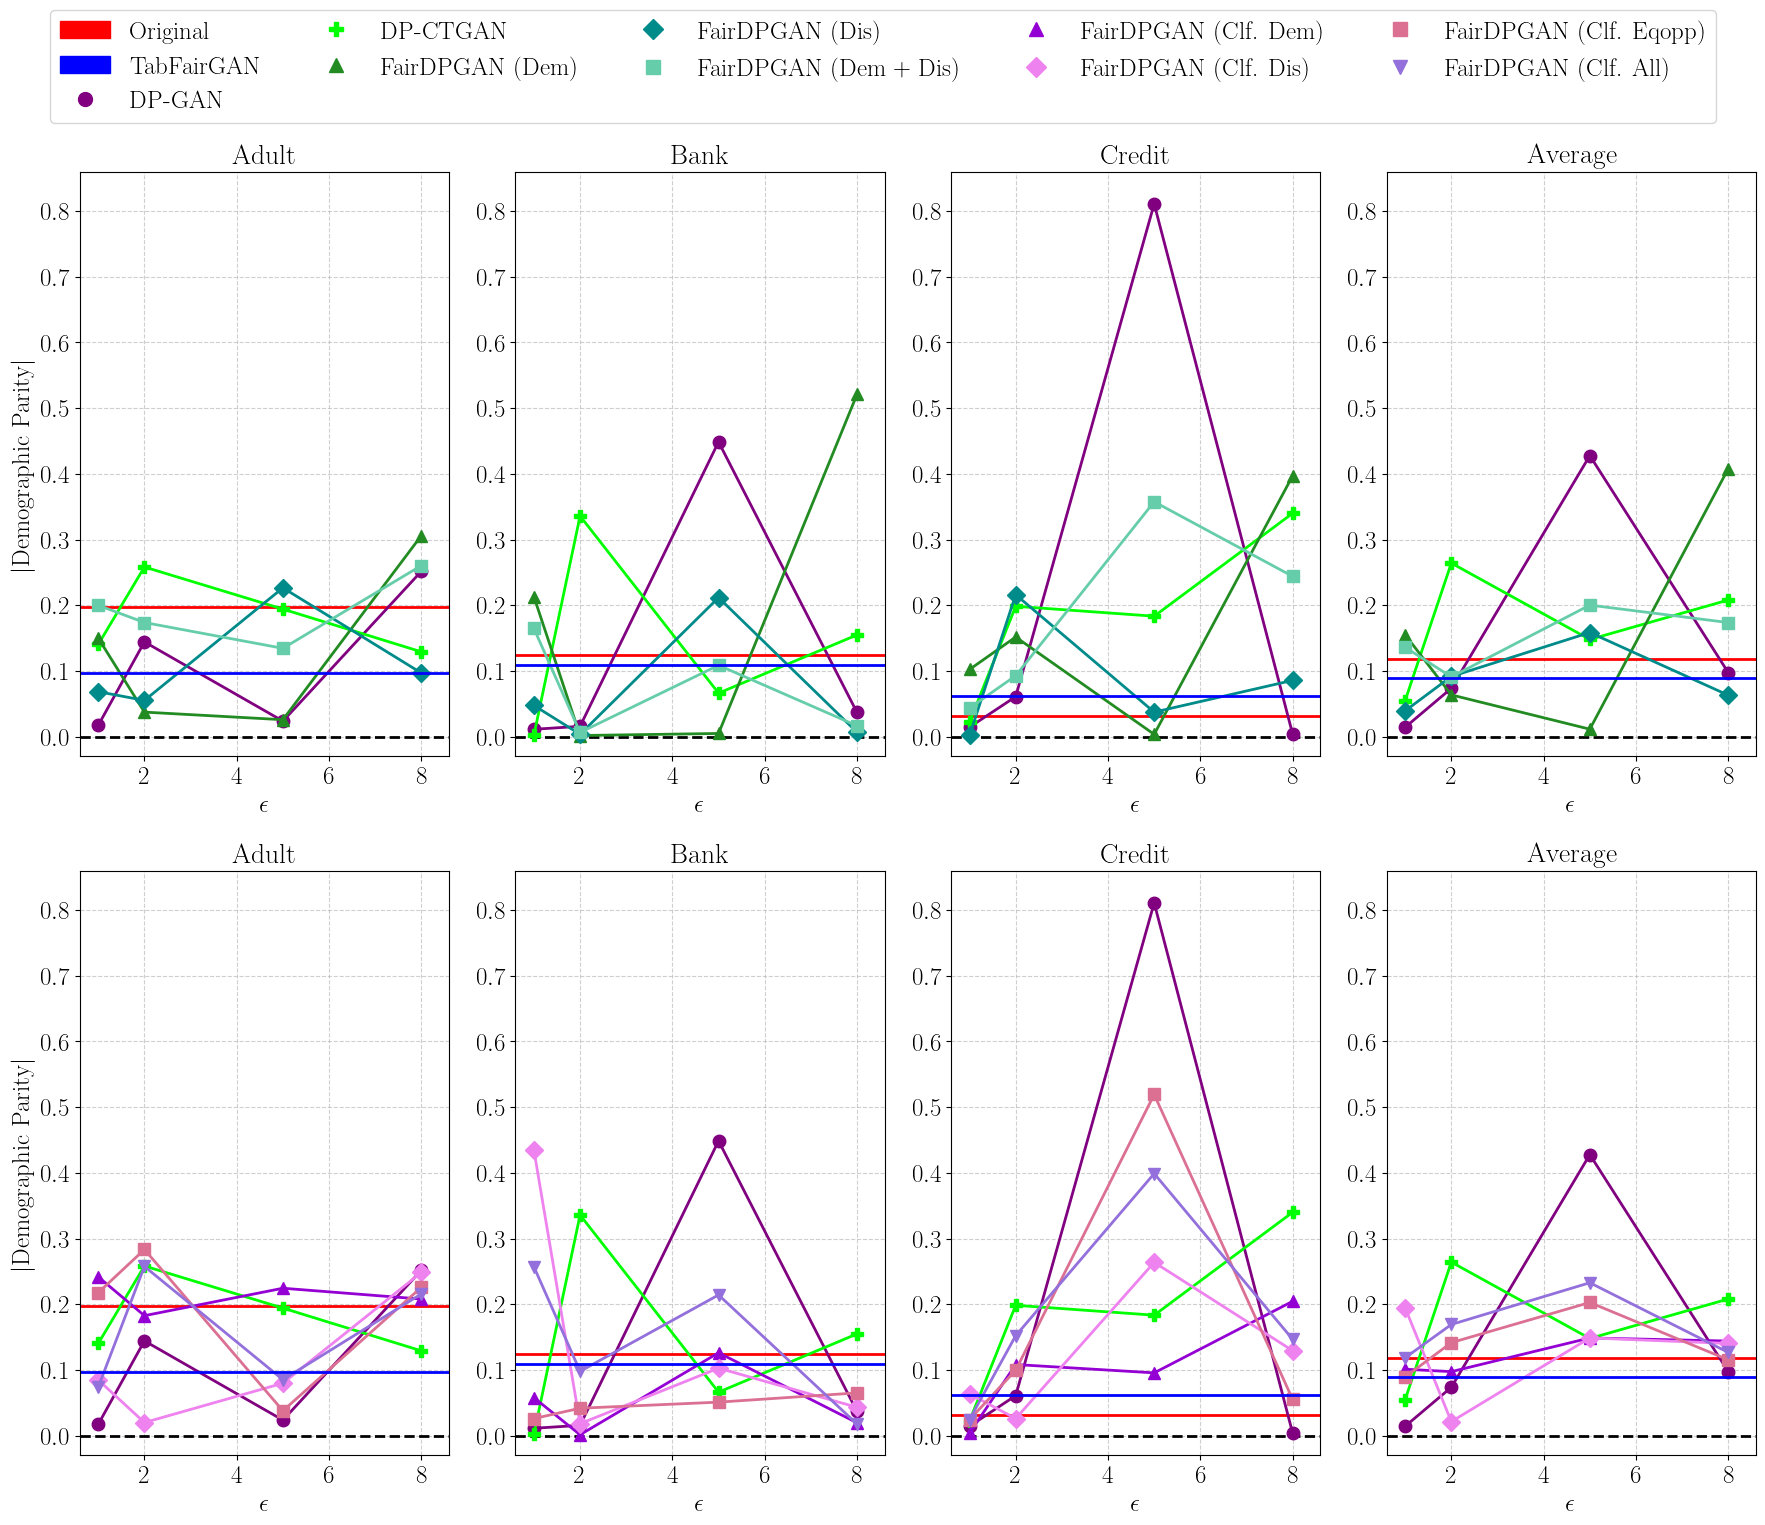

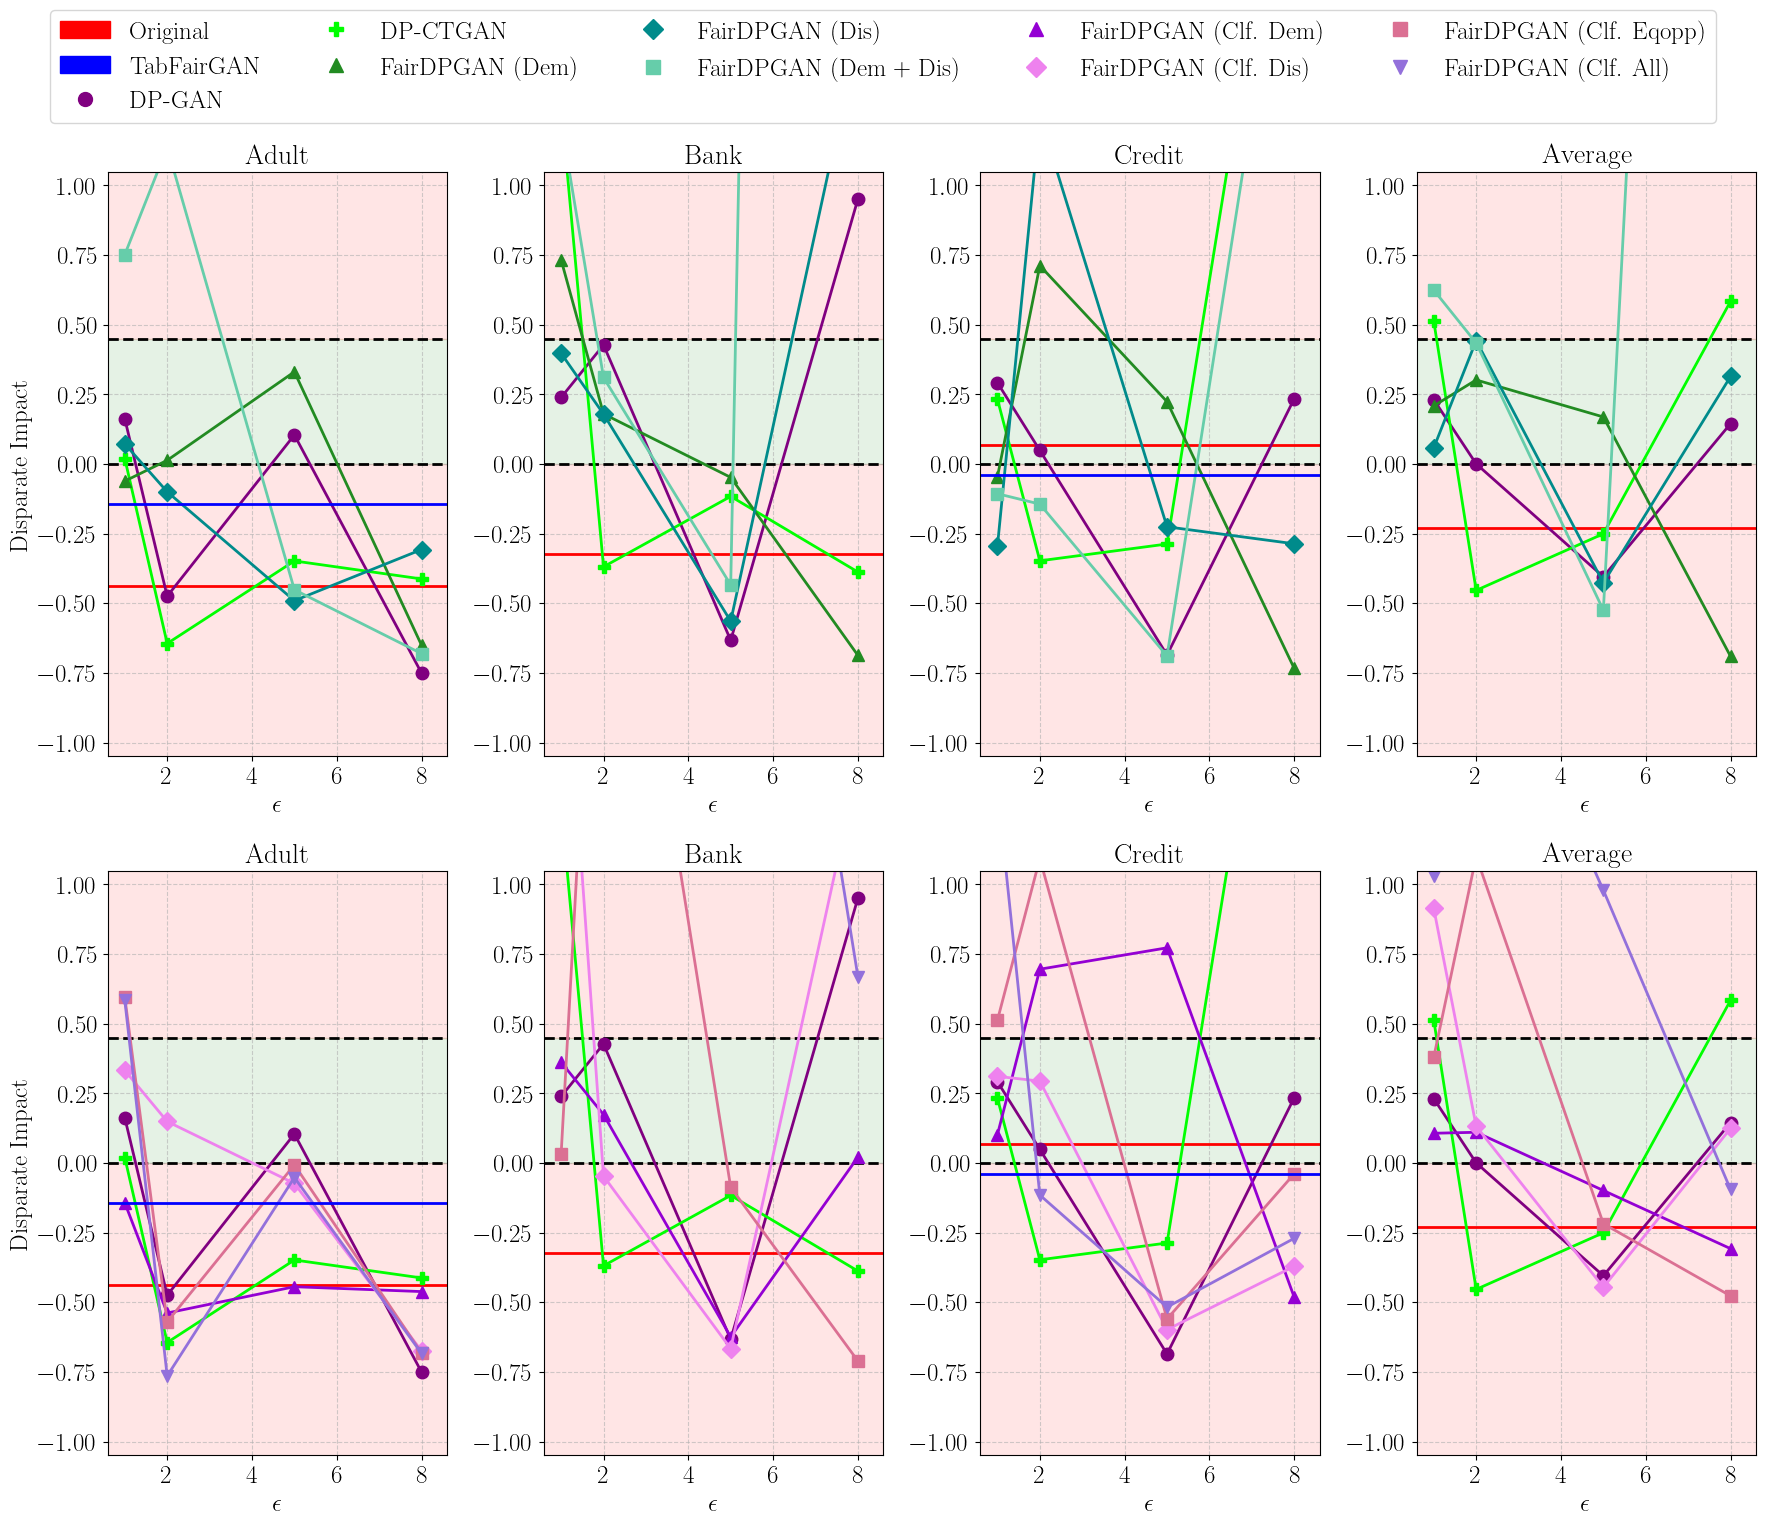

In [71]:
# Plotting dataset fairness metrics of the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)", "FairDPGAN (Clf. Dem)", 
          "FairDPGAN (Clf. Dis)", "FairDPGAN (Clf. Eqopp)", "FairDPGAN (Clf. All)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine", "darkviolet", "violet", "palevioletred", "mediumpurple"]
markers = ["o", "P", "^", "D", "s", "^", "D", "s", "v"]
msize = 9

limits = {"dem-parity": (-0.03, 0.86), "dis-impact": (-1.05, 1.05)}

fairness_clf = ["dem-parity", "dis-impact"]
fairness_labels = ["Demographic Parity", "Disparate Impact"]

for f in fairness_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (18, 15.0))  # 2 x 4 grid
    for r in range(0, 2):
        for c in range(0, 4):
            if c == 0:
                dataset = "Adult"
                results_np = pd.concat([adult_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([adult_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([adult_results_DP[f], adult_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([adult_results_DPC[f], adult_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([adult_results_dem[f], adult_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([adult_results_dis[f], adult_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([adult_results_demdi[f], adult_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([adult_results_fcdem[f], adult_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([adult_results_fcdis[f], adult_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([adult_results_feqopp[f], adult_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([adult_results_fall[f], adult_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 1:
                dataset = "Bank"
                results_np = pd.concat([bank_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([bank_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([bank_results_DP[f], bank_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([bank_results_DPC[f], bank_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([bank_results_dem[f], bank_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([bank_results_dis[f], bank_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([bank_results_demdi[f], bank_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([bank_results_fcdem[f], bank_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([bank_results_fcdis[f], bank_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([bank_results_feqopp[f], bank_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([bank_results_fall[f], bank_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 2:
                dataset = "Credit"
                results_np = pd.concat([credit_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([credit_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([credit_results_DP[f], credit_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([credit_results_DPC[f], credit_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([credit_results_dem[f], credit_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([credit_results_dis[f], credit_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([credit_results_demdi[f], credit_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([credit_results_fcdem[f], credit_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([credit_results_fcdis[f], credit_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([credit_results_feqopp[f], credit_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([credit_results_fall[f], credit_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            else:
                dataset = "Average"
                if f == "dem-parity":
                    results = pd.DataFrame({"mean": [np.mean(avg_dem_real)] + list(np.mean(avg_dem_DP, axis = 1)),
                                               "std": [np.std(avg_dem_real)] + list(np.std(avg_dem_DP, axis = 1))},
                                              index = ["Real", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_CT = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_CT, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_CT, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                    results_fdem = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdem, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdem, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_fdis = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdis, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdis, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_fdemdi = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdemdi, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdemdi, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                    results_fcdem = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fcdem, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fcdem, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_fcdis = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fcdis, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fcdis, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_feqopp = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_feqopp, axis = 1)), 
                                                   "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_feqopp, axis = 1))},
                                                  index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_fall = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fall, axis = 1)), 
                                                   "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fall, axis = 1))},
                                                  index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                else:
                    results = pd.DataFrame({"mean": [np.mean(avg_dis_real)] + list(np.mean(avg_dis_DP, axis = 1)),
                                               "std": [np.std(avg_dis_real)] + list(np.std(avg_dis_DP, axis = 1))},
                                              index = ["Real", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_CT = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_CT, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_CT, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                    results_fdem = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdem, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdem, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_fdis = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdis, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdis, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    
                    results_fdemdi = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdemdi, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdemdi, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                    results_fcdem = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fcdem, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fcdem, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_fcdis = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fcdis, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fcdis, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_feqopp = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_feqopp, axis = 1)), 
                                                   "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_feqopp, axis = 1))},
                                                  index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                    results_fall = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fall, axis = 1)), 
                                                   "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fall, axis = 1))},
                                                  index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                
            # Customizing the plot.
            col = fairness_clf.index(f)
            ax = axes[r, c]
            ax.set_title(f"{dataset}")
            if c == 0:
                if f == "dis-impact":
                    ax.set_ylabel(fairness_labels[col])
                else:
                    ax.set_ylabel(f"$|${fairness_labels[col]}$|$")
            ax.set_aspect('auto')
            ax.set_xlabel(r"$\epsilon$")
            ax.set_xlim([0.6, 8.6])
            ax.set_ylim(limits[f][0], limits[f][1])
            ax.grid(True, linestyle = '--', alpha = 0.6)
    
            # Plotting a dashed line for the demographic parity and disparate impact parameters.
            ax.axhline(0, 0, 5, ls = "--", c = "black")

            if f == "dis-impact":
                # Plotting another dashed line for the disparate impact parameter.
                ax.axhline(0.45, 0, 5, ls = "--", c = "black")
                # Plotting three rectangular patches for the disparate impact parameter.
                rect1 = mpatches.Rectangle(xy = (-0.5, 0), width = 10.5, height = 0.45, color='green', alpha = 0.1, ec='green')
                ax.add_patch(rect1)
                rect2 = mpatches.Rectangle(xy = (-0.5, 0), width = 10.5, height = -10.5, color='red', alpha = 0.1, ec='red')
                ax.add_patch(rect2)
                rect3 = mpatches.Rectangle(xy = (-0.5, 0.45), width = 10.5, height = 10.5, color='red', alpha = 0.1, ec='red')
                ax.add_patch(rect3)

            # Create line plots for the current metric: Adult, Bank, Credit & Average.
            ax.plot([0, 11], [results.iloc[0][0]]*len([0, 11]), color = colors[0])   # original
            if r == 0:
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fdem.iloc[0][1:5], color = colors[4], marker = markers[2], markersize = msize)   
                ax.plot(epsi, results_fdis.iloc[0][1:5], color = colors[5], marker = markers[3], markersize = msize)
                ax.plot(epsi, results_fdemdi.iloc[0][1:5], color = colors[6], marker = markers[4], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = "blue")   # TabFairGAN
            else:   # Classifier Fair DP-GANs
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fcdem.iloc[0][1:5], color = colors[7], marker = markers[5], markersize = msize)   
                ax.plot(epsi, results_fcdis.iloc[0][1:5], color = colors[8], marker = markers[6], markersize = msize)
                ax.plot(epsi, results_feqopp.iloc[0][1:5], color = colors[9], marker = markers[7], markersize = msize)
                ax.plot(epsi, results_fall.iloc[0][1:5], color = colors[10], marker = markers[8], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = colors[1])   # TabFairGAN

        if r == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 5, loc = "upper center", bbox_to_anchor = (0.5, 1.03))
            
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

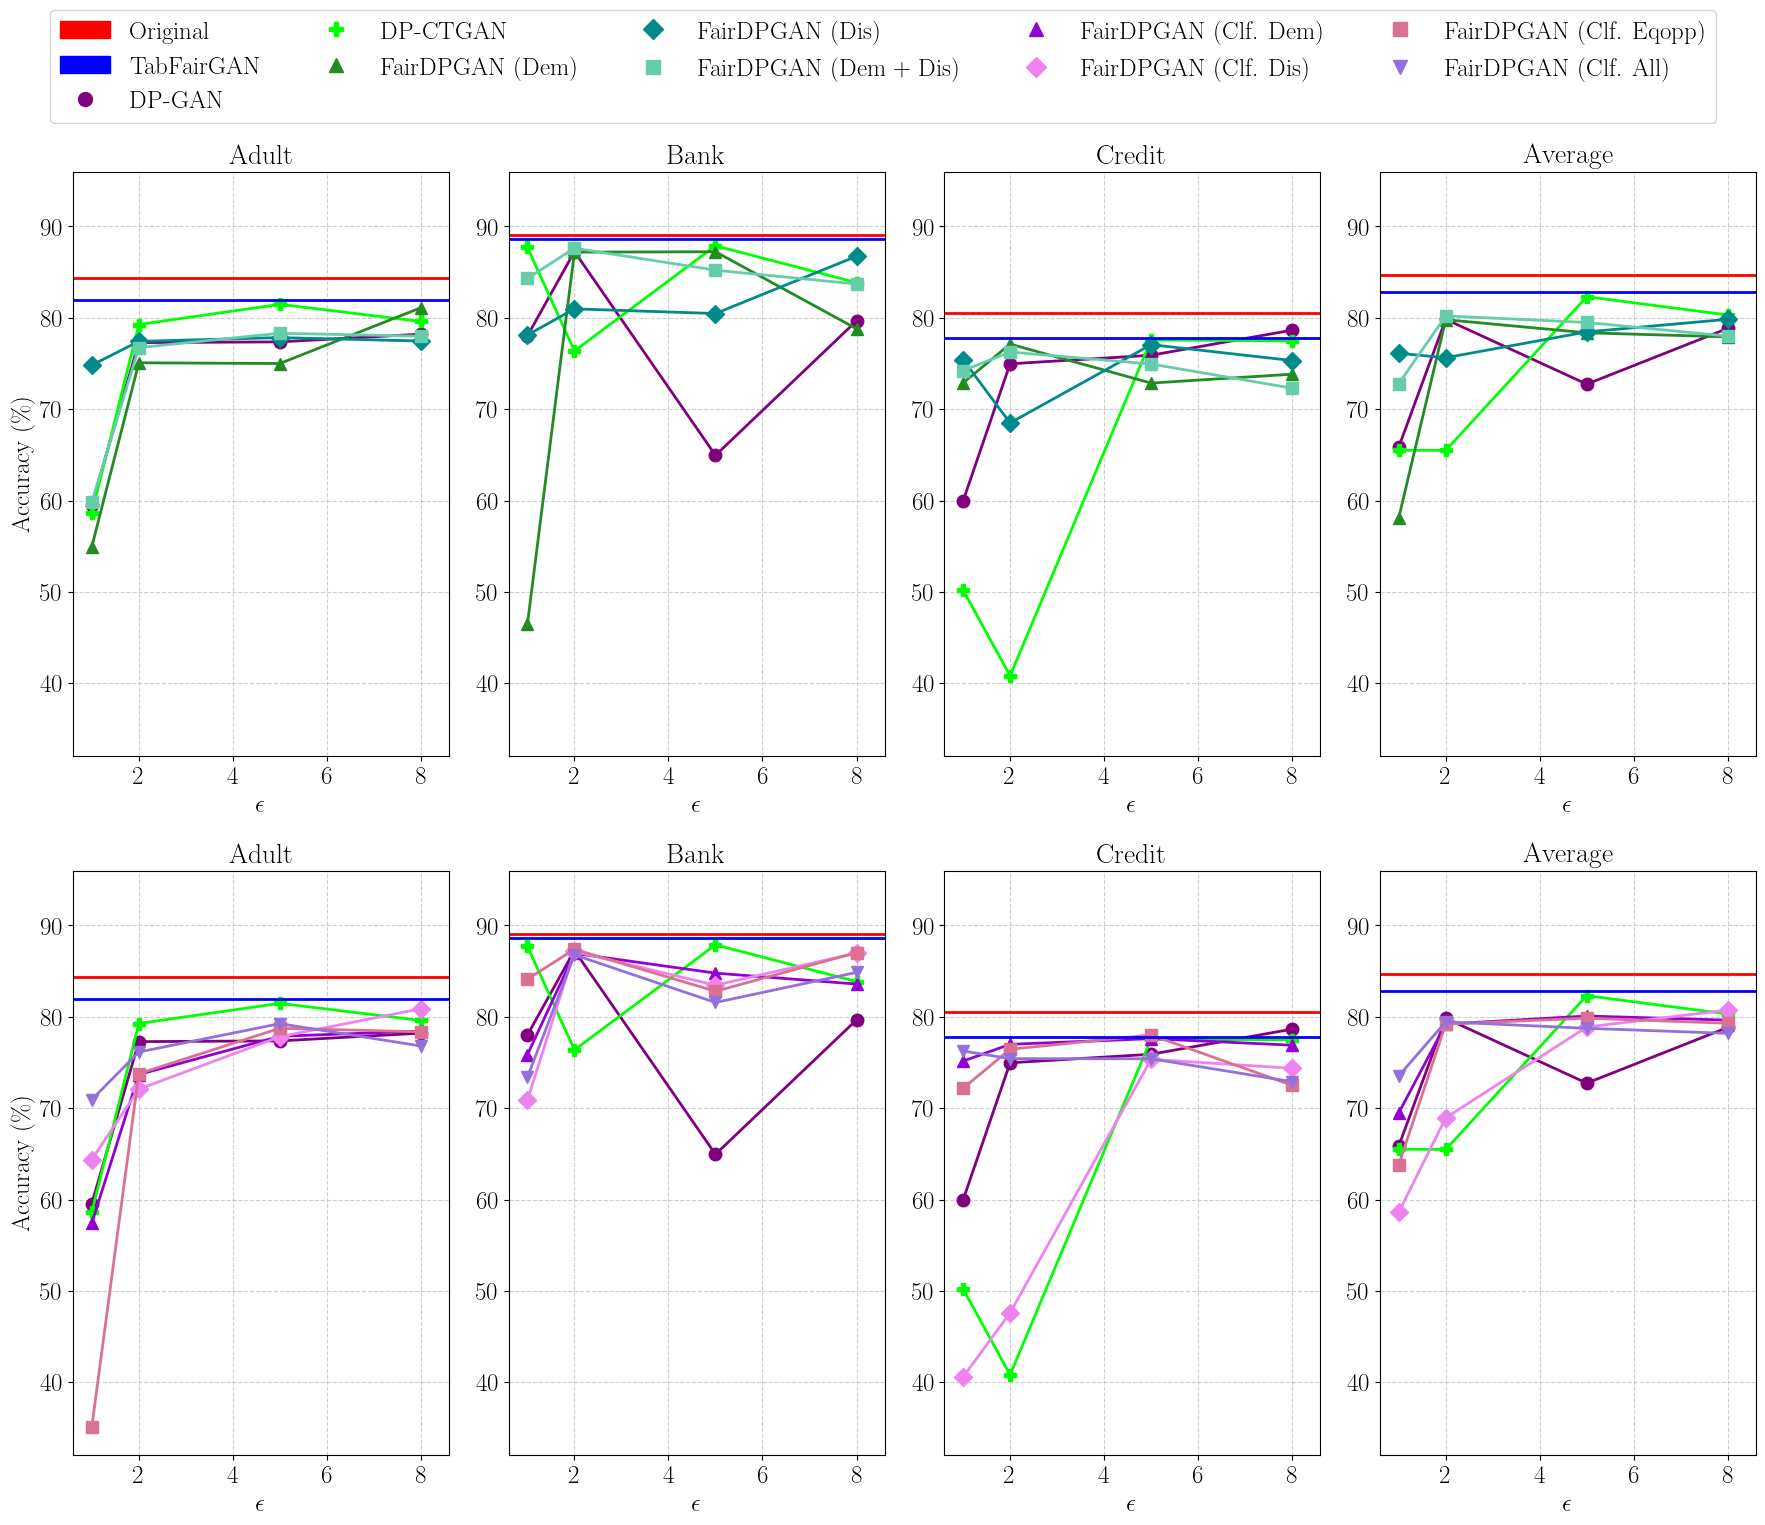

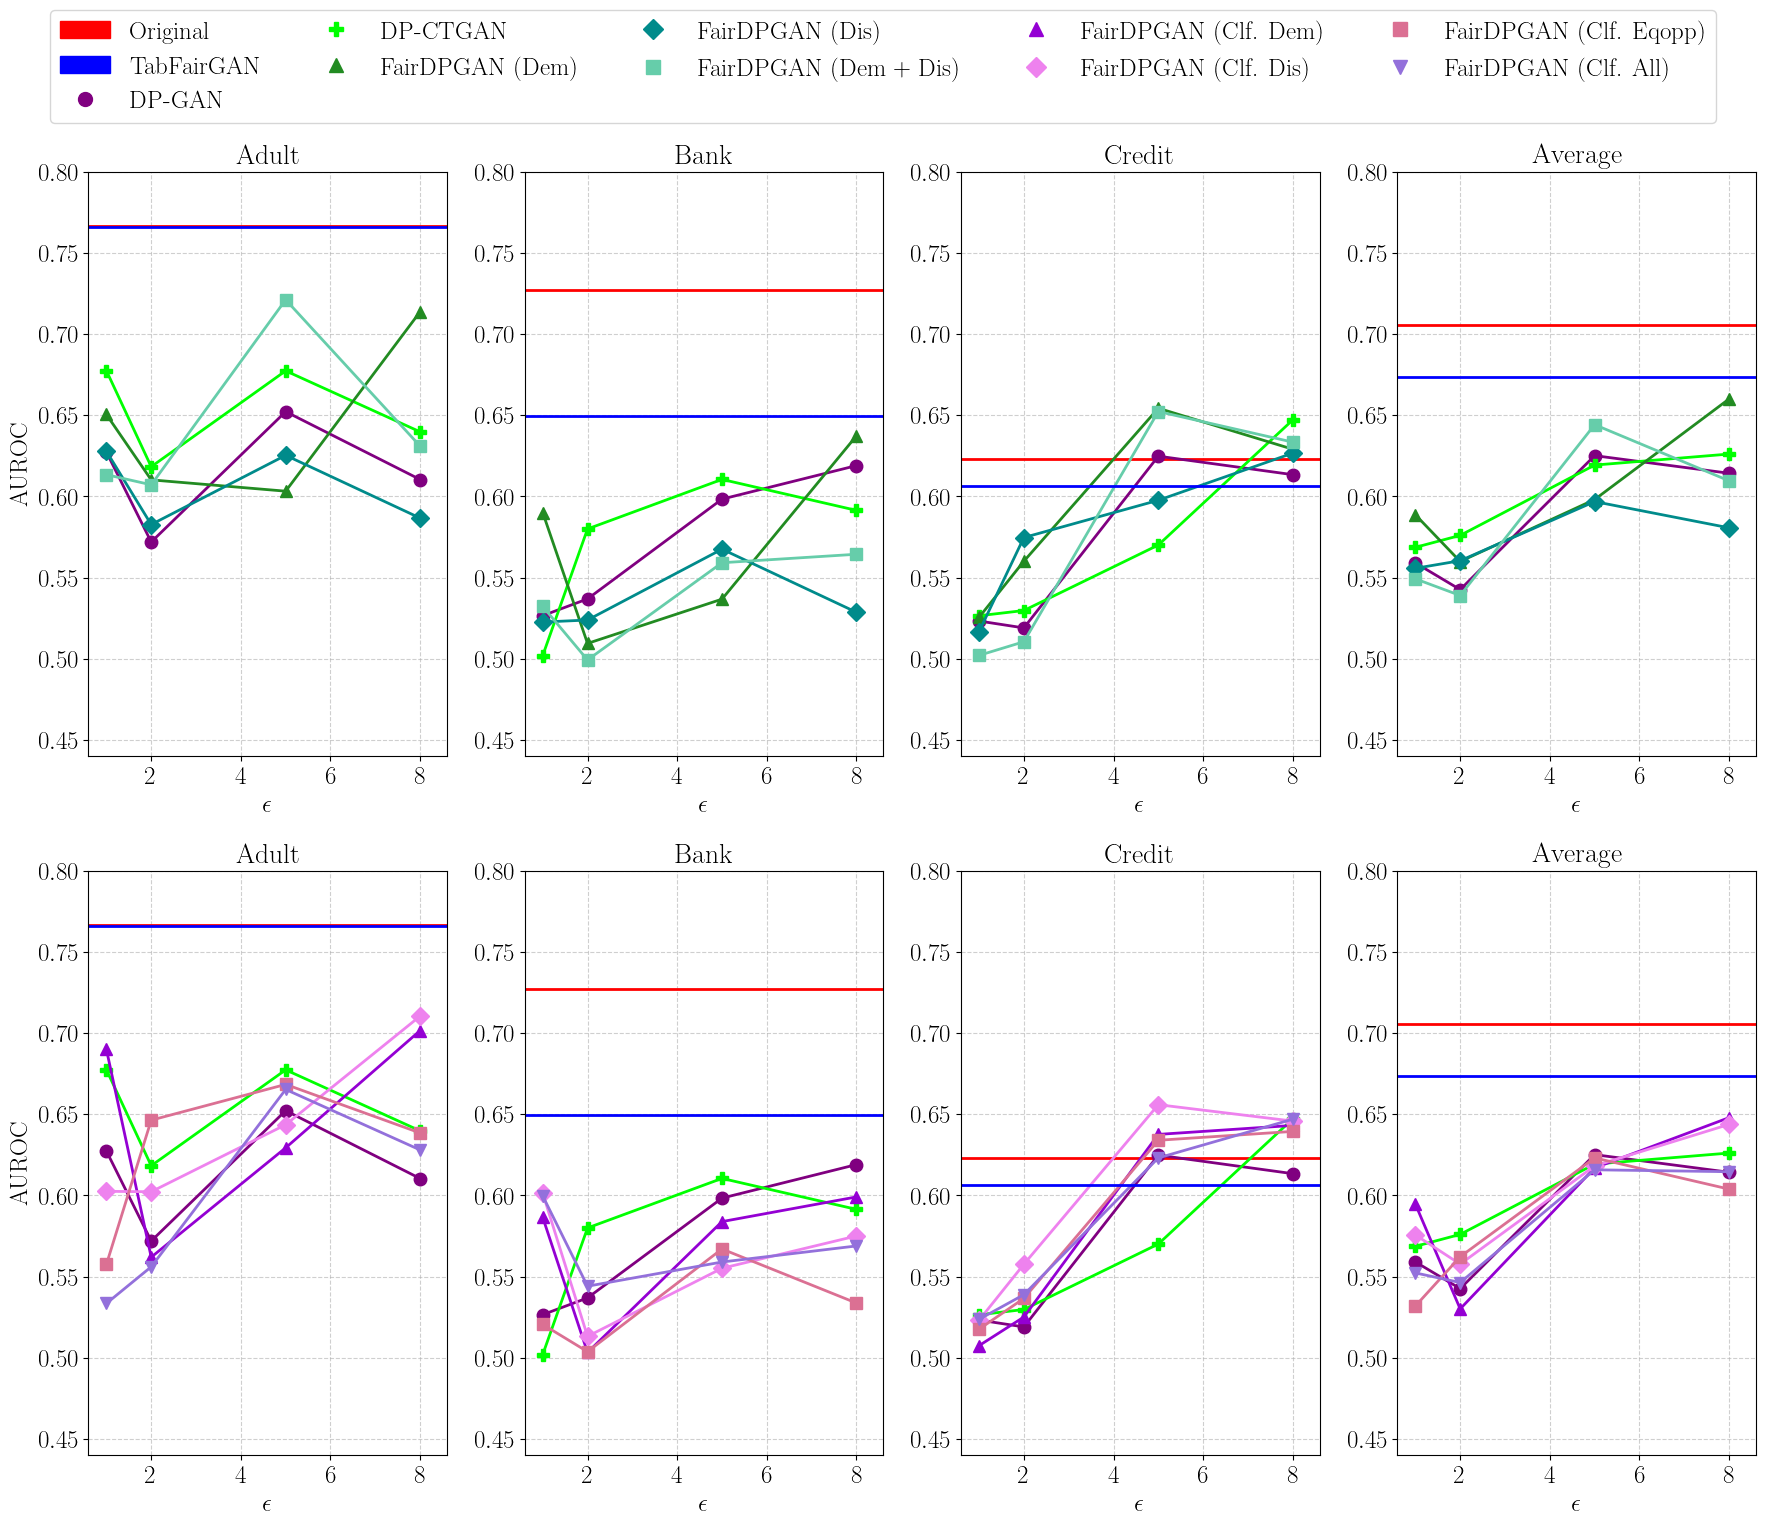

In [72]:
# Plotting utility metrics of classifiers trained on the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)", "FairDPGAN (Clf. Dem)", 
          "FairDPGAN (Clf. Dis)", "FairDPGAN (Clf. Eqopp)", "FairDPGAN (Clf. All)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine", "darkviolet", "violet", "palevioletred", "mediumpurple"]
markers = ["o", "P", "^", "D", "s", "^", "D", "s", "v"]
msize = 9

limits = {"acc": (32, 96), "auroc": (0.44, 0.80)}

utility_clf = ["acc", "auroc"]
utility_labels = ["Accuracy (\%)", "AUROC"]

for u in utility_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (18, 15.0))  # 2 x 4 grid
    for r in range(0, 2):
        for c in range(0, 4):
            if c == 0:
                dataset = "Adult"
                results_np = pd.concat([adult_results[u]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([adult_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([adult_results_DP[u], adult_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([adult_results_DPC[u], adult_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([adult_results_dem[u], adult_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([adult_results_dis[u], adult_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([adult_results_demdi[u], adult_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([adult_results_fcdem[u], adult_results_fcdem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([adult_results_fcdis[u], adult_results_fcdis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([adult_results_feqopp[u], adult_results_feqopp_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([adult_results_fall[u], adult_results_fall_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 1:
                dataset = "Bank"
                results_np = pd.concat([bank_results[u]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([bank_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([bank_results_DP[u], bank_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([bank_results_DPC[u], bank_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([bank_results_dem[u], bank_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([bank_results_dis[u], bank_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([bank_results_demdi[u], bank_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([bank_results_fcdem[u], bank_results_fcdem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([bank_results_fcdis[u], bank_results_fcdis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([bank_results_feqopp[u], bank_results_feqopp_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([bank_results_fall[u], bank_results_fall_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 2:
                dataset = "Credit"
                results_np = pd.concat([credit_results[u]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([credit_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([credit_results_DP[u], credit_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([credit_results_DPC[u], credit_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([credit_results_dem[u], credit_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([credit_results_dis[u], credit_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([credit_results_demdi[u], credit_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([credit_results_fcdem[u], credit_results_fcdem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([credit_results_fcdis[u], credit_results_fcdis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([credit_results_feqopp[u], credit_results_feqopp_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([credit_results_fall[u], credit_results_fall_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            else:
                dataset = "Average"
                results_np = pd.concat([avg_real_results[u]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([avg_TF_results[u]], axis = 1).set_axis(["TF"], axis = 1)

                results_DP = pd.concat([avg_DP_results[u], avg_DP_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([avg_CT_results[u], avg_CT_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([avg_fdem_results[u], avg_fdem_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([avg_fdis_results[u], avg_fdis_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([avg_fdemdi_results[u], avg_fdemdi_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([avg_fcdem_results[u], avg_fcdem_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([avg_fcdis_results[u], avg_fcdis_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([avg_feqopp_results[u], avg_feqopp_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([avg_fall_results[u], avg_fall_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
    
            # Customizing the plot.
            col = utility_clf.index(u)
            ax = axes[r, c]
            ax.set_title(f"{dataset}")
            if c == 0:
                ax.set_ylabel(utility_labels[col])
            ax.set_aspect('auto')
            ax.set_xlim([0.6, 8.6])
            ax.set_ylim(limits[u][0], limits[u][1])
            ax.set_xlabel(r"$\epsilon$")
            ax.grid(True, linestyle = '--', alpha = 0.6)

            # Create line plots for the current metric: Adult, Bank, Credit & Average.
            ax.plot([0, 11], [results.iloc[0][0]]*len([0, 11]), color = colors[0])   # original
            if r == 0:
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fdem.iloc[0][1:5], color = colors[4], marker = markers[2], markersize = msize)   
                ax.plot(epsi, results_fdis.iloc[0][1:5], color = colors[5], marker = markers[3], markersize = msize)
                ax.plot(epsi, results_fdemdi.iloc[0][1:5], color = colors[6], marker = markers[4], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = "blue")   # TabFairGAN
            else:   # Classifier Fair DP-GANs
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fcdem.iloc[0][1:5], color = colors[7], marker = markers[5], markersize = msize)   
                ax.plot(epsi, results_fcdis.iloc[0][1:5], color = colors[8], marker = markers[6], markersize = msize)
                ax.plot(epsi, results_feqopp.iloc[0][1:5], color = colors[9], marker = markers[7], markersize = msize)
                ax.plot(epsi, results_fall.iloc[0][1:5], color = colors[10], marker = markers[8], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = colors[1])   # TabFairGAN

        if r == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 5, loc = "upper center", bbox_to_anchor = (0.5, 1.03))
            
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

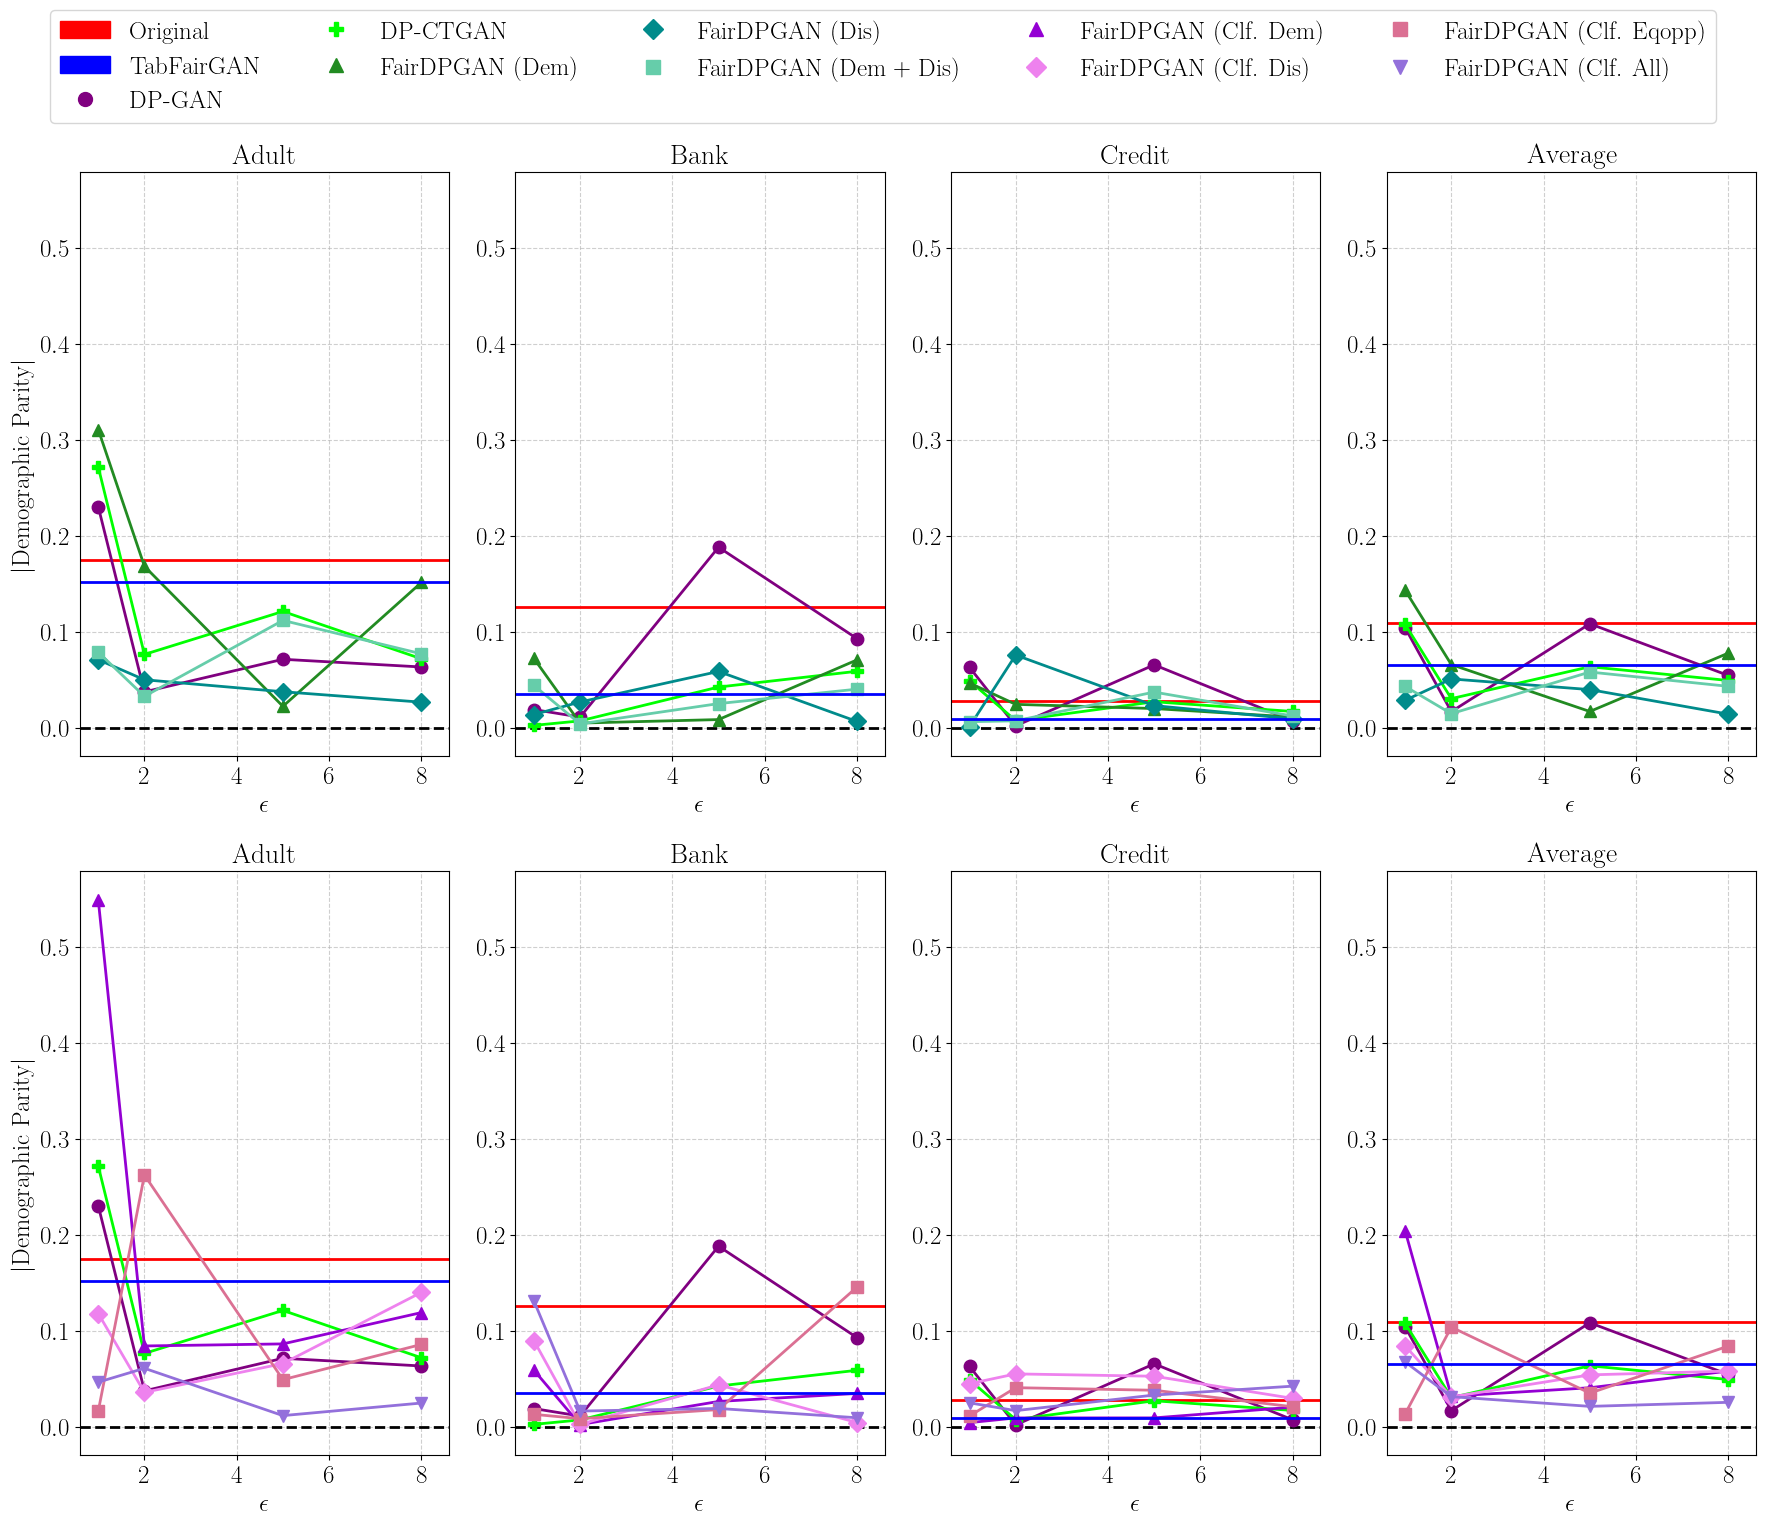

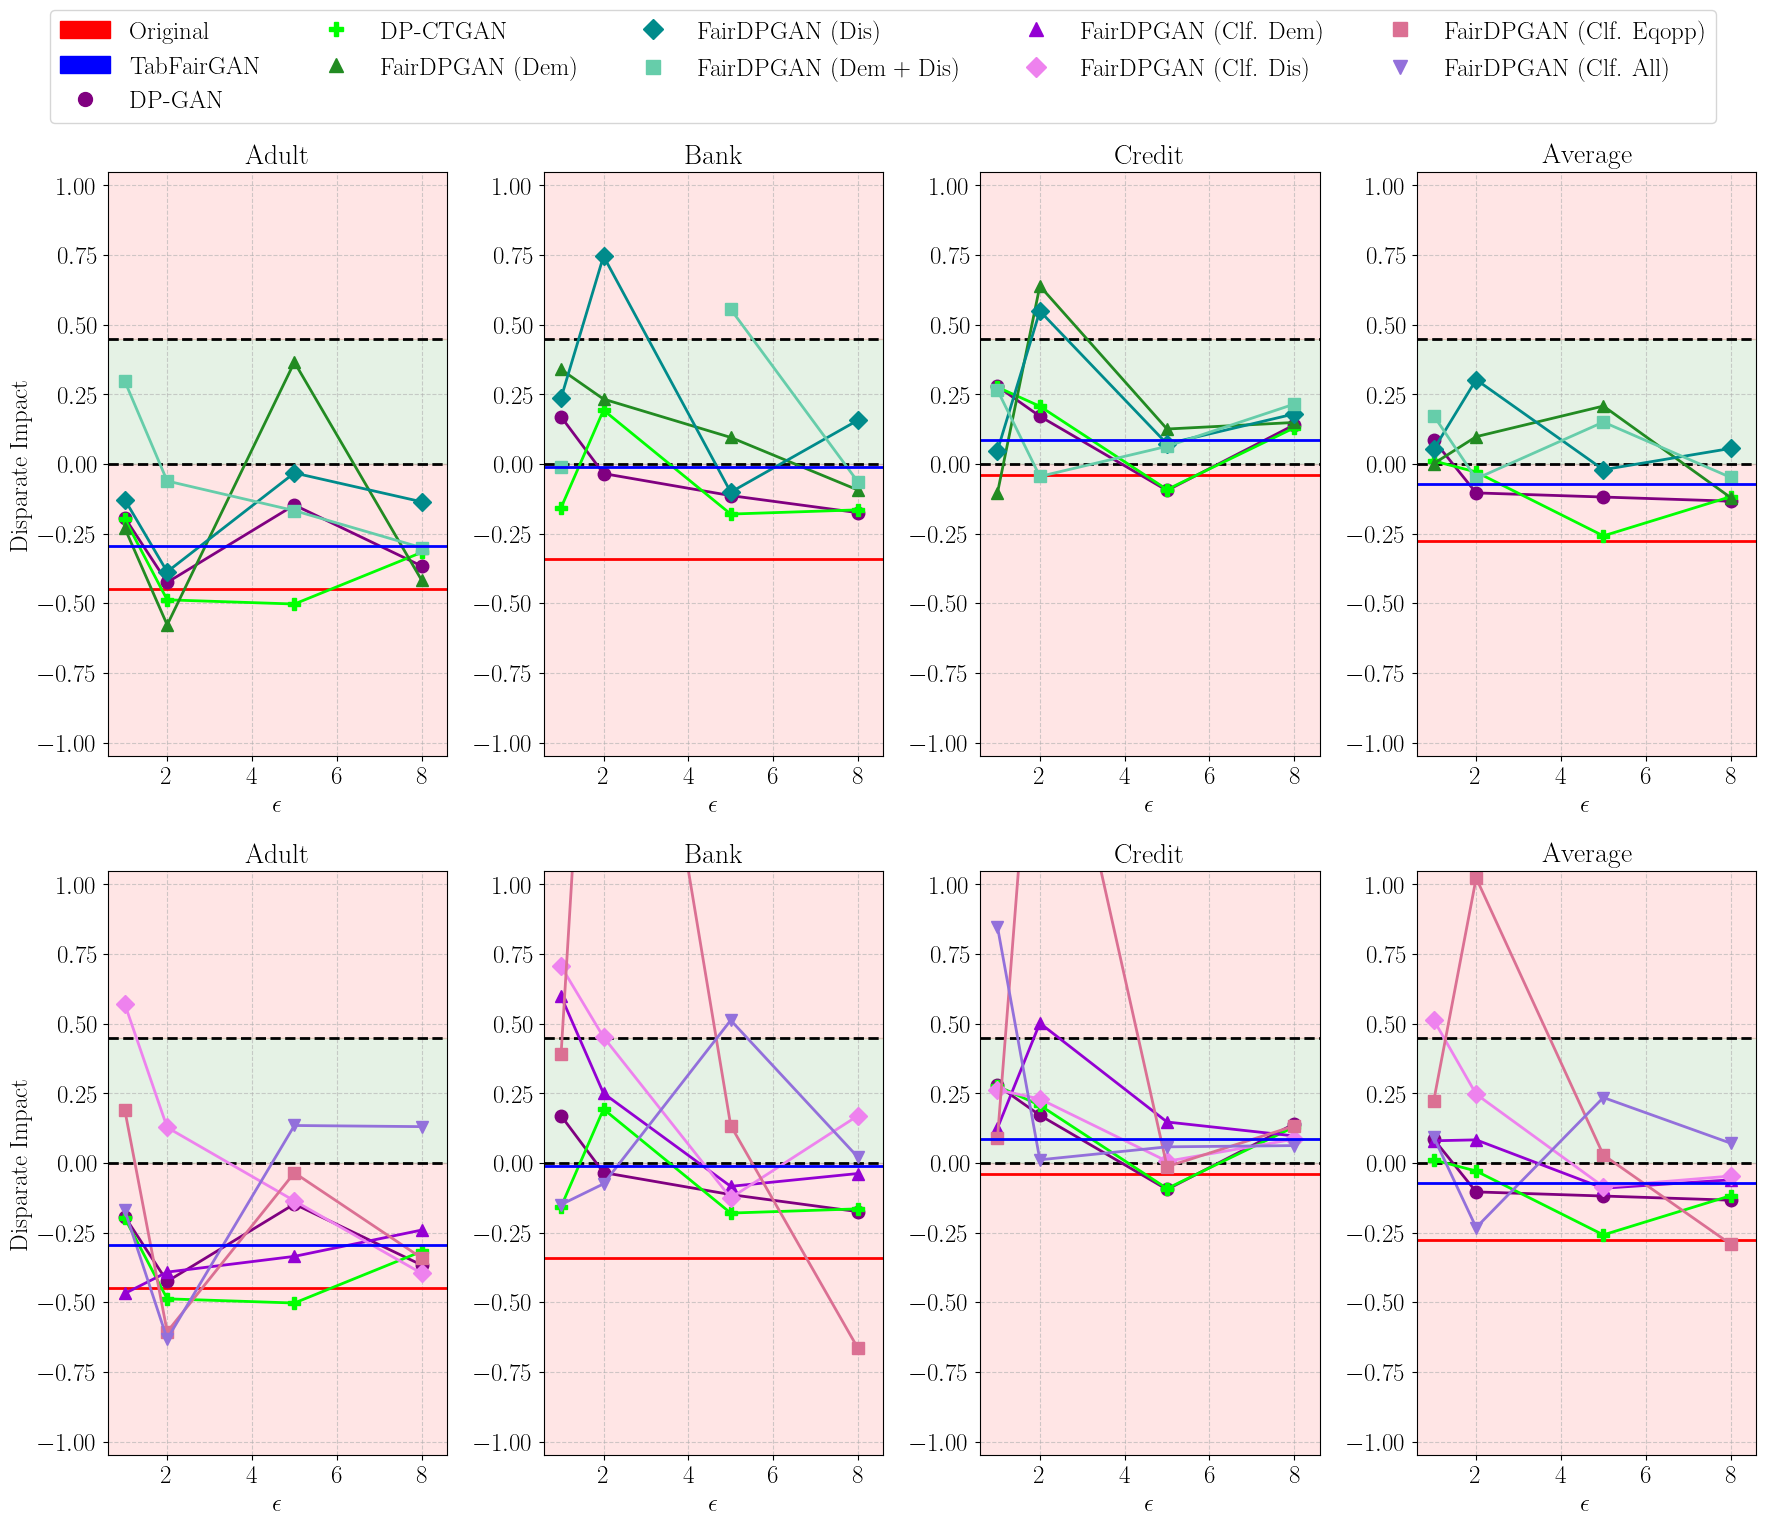

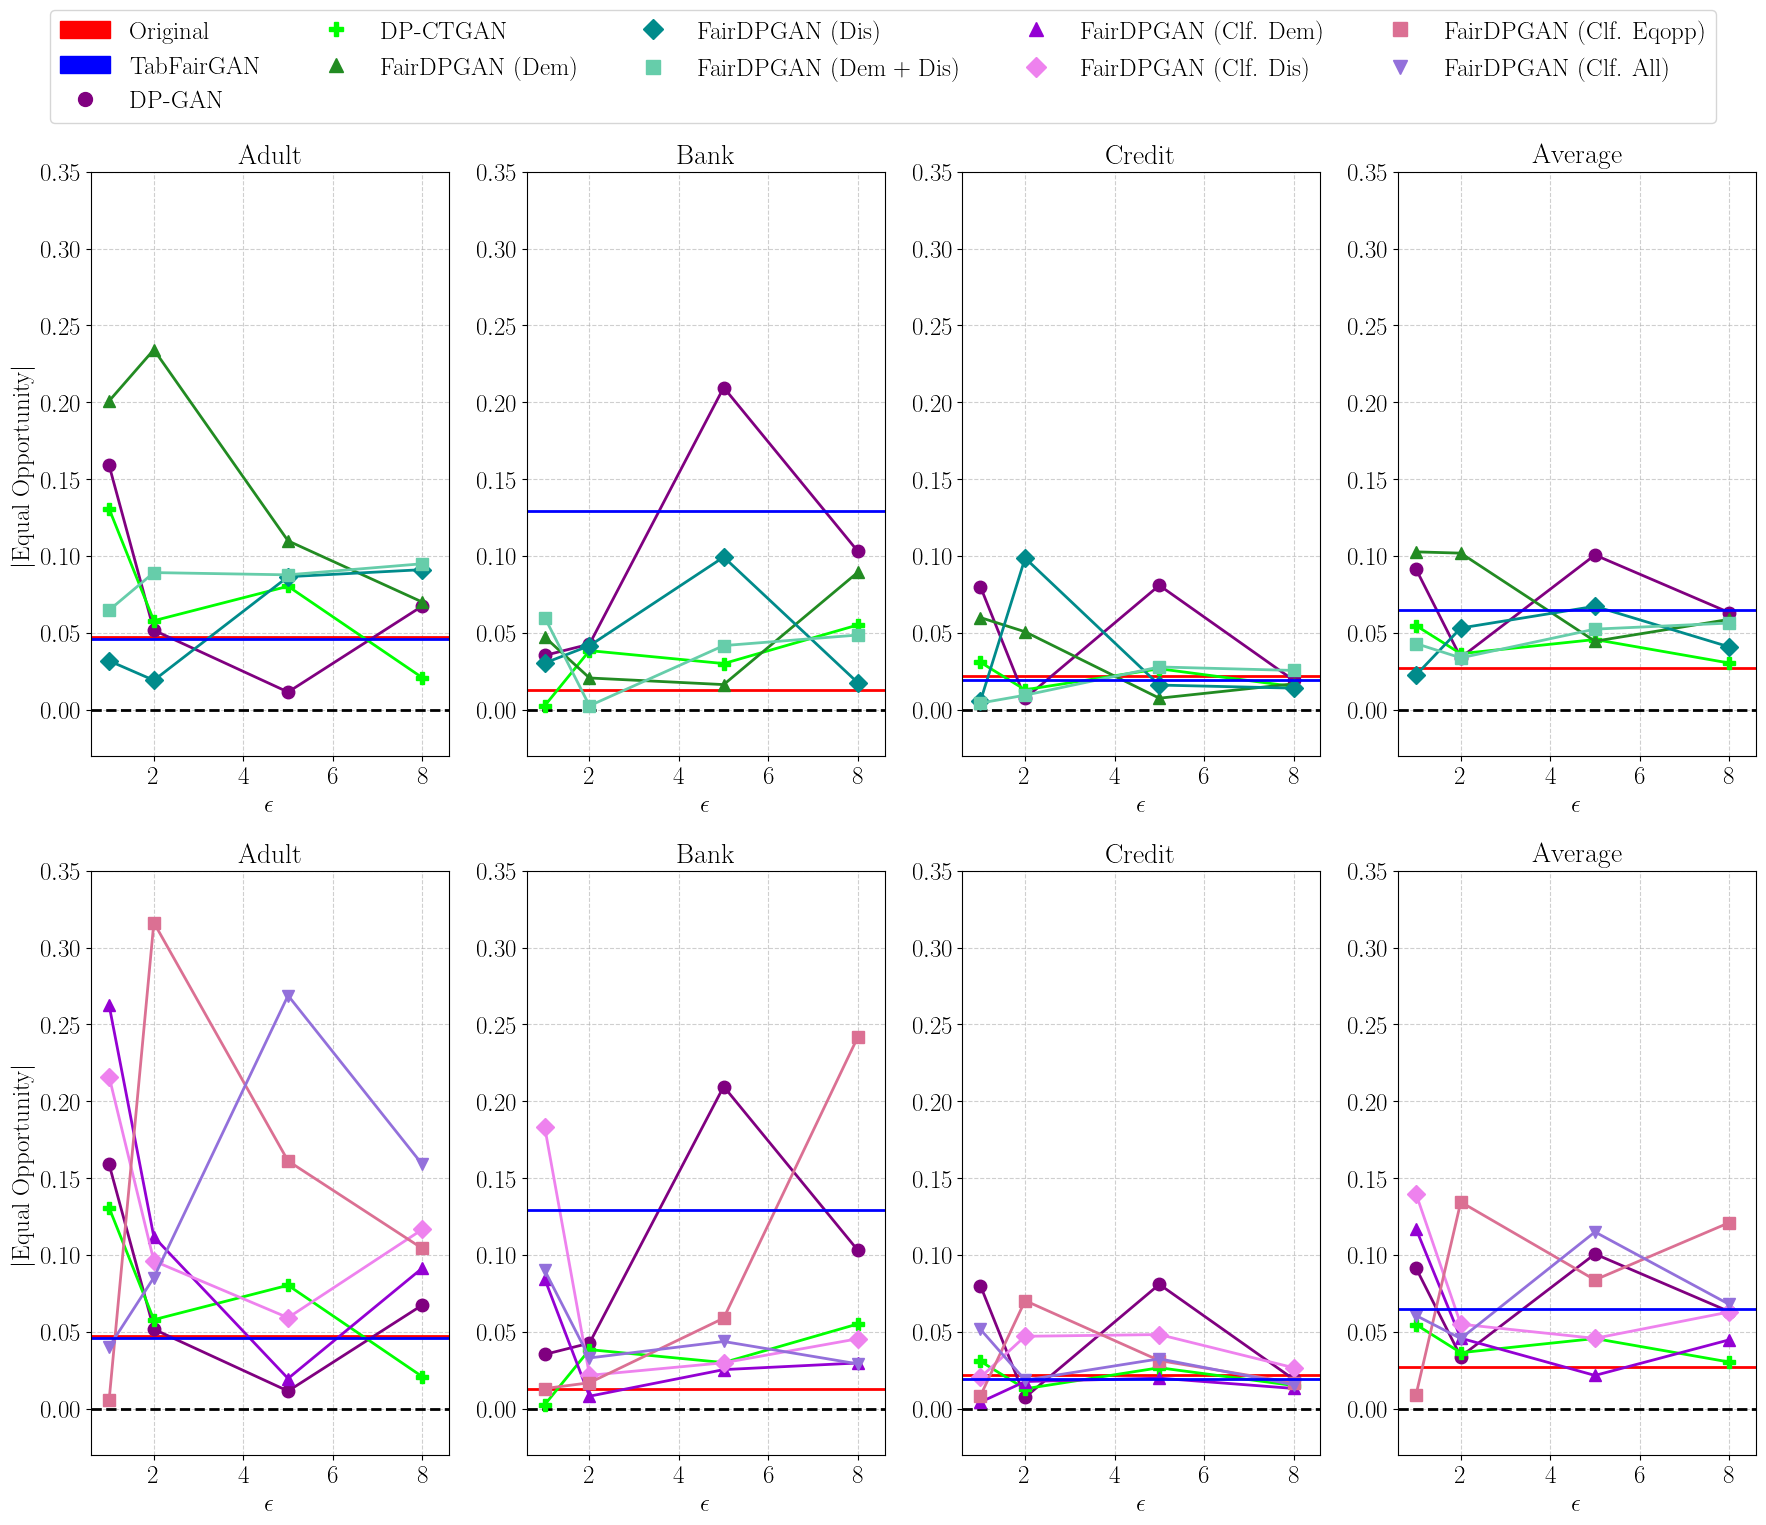

In [73]:
# Plotting fairness metrics of classifiers trained on the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)", "FairDPGAN (Clf. Dem)", 
          "FairDPGAN (Clf. Dis)", "FairDPGAN (Clf. Eqopp)", "FairDPGAN (Clf. All)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine", "darkviolet", "violet", "palevioletred", "mediumpurple"]
markers = ["o", "P", "^", "D", "s", "^", "D", "s", "v"]
msize = 9

limits = {"dem": (-0.03, 0.58), "dis": (-1.05, 1.05), "eqopp": (-0.03, 0.35)}

fairness_clf = ["dem", "dis", "eqopp"]
fairness_labels = ["Demographic Parity", "Disparate Impact", "Equal Opportunity"]

for f in fairness_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (18, 15.0))  # 2 x 4 grid
    for r in range(0, 2):
        for c in range(0, 4):
            if c == 0:
                dataset = "Adult"
                results_np = pd.concat([adult_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([adult_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([adult_results_DP[f], adult_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([adult_results_DPC[f], adult_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([adult_results_dem[f], adult_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([adult_results_dis[f], adult_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([adult_results_demdi[f], adult_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([adult_results_fcdem[f], adult_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([adult_results_fcdis[f], adult_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([adult_results_feqopp[f], adult_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([adult_results_fall[f], adult_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 1:
                dataset = "Bank"
                results_np = pd.concat([bank_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([bank_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([bank_results_DP[f], bank_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([bank_results_DPC[f], bank_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([bank_results_dem[f], bank_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([bank_results_dis[f], bank_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([bank_results_demdi[f], bank_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([bank_results_fcdem[f], bank_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([bank_results_fcdis[f], bank_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([bank_results_feqopp[f], bank_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([bank_results_fall[f], bank_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            elif c == 2:
                dataset = "Credit"
                results_np = pd.concat([credit_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([credit_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
                results_DP = pd.concat([credit_results_DP[f], credit_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([credit_results_DPC[f], credit_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([credit_results_dem[f], credit_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([credit_results_dis[f], credit_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([credit_results_demdi[f], credit_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([credit_results_fcdem[f], credit_results_fcdem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([credit_results_fcdis[f], credit_results_fcdis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([credit_results_feqopp[f], credit_results_feqopp_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([credit_results_fall[f], credit_results_fall_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
            else:
                dataset = "Average"
                results_np = pd.concat([avg_real_results[f]], axis = 1).set_axis(["Real"], axis = 1)
                results_TF = pd.concat([avg_TF_results[f]], axis = 1).set_axis(["TF"], axis = 1)

                results_DP = pd.concat([avg_DP_results[f], avg_DP_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results = pd.concat([results_np, results_DP], axis = 1)

                results_DPC = pd.concat([avg_CT_results[f], avg_CT_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_CT = pd.concat([results_TF, results_DPC], axis = 1)

                results_fdemDP = pd.concat([avg_fdem_results[f], avg_fdem_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

                results_fdisDP = pd.concat([avg_fdis_results[f], avg_fdis_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

                results_fdemdiDP = pd.concat([avg_fdemdi_results[f], avg_fdemdi_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

                results_fcdemDP = pd.concat([avg_fcdem_results[f], avg_fcdem_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdem = pd.concat([results_np, results_fcdemDP], axis = 1)

                results_fcdisDP = pd.concat([avg_fcdis_results[f], avg_fcdis_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fcdis = pd.concat([results_np, results_fcdisDP], axis = 1)

                results_feqoppDP = pd.concat([avg_feqopp_results[f], avg_feqopp_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_feqopp = pd.concat([results_np, results_feqoppDP], axis = 1)

                results_fallDP = pd.concat([avg_fall_results[f], avg_fall_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
                results_fall = pd.concat([results_np, results_fallDP], axis = 1)
        
            # Customizing the plot.
            col = fairness_clf.index(f)
            ax = axes[r, c]
            ax.set_title(f"{dataset}")
            if c == 0:
                if f == "dis":
                    ax.set_ylabel(fairness_labels[col])
                else:
                    ax.set_ylabel(f"$|${fairness_labels[col]}$|$")
            ax.set_aspect('auto')
            ax.set_xlim([0.6, 8.6])
            ax.set_ylim(limits[f][0], limits[f][1])
            ax.set_xlabel(r"$\epsilon$")
            ax.grid(True, linestyle = '--', alpha = 0.6)
    
            # Plotting a dashed line for the demographic parity, disparate impact and equal opportunity parameters.
            ax.axhline(0, 0, 5, ls = "--", c = "black")

            if f == "dis":
                # Plotting another dashed line for the disparate impact parameter.
                ax.axhline(0.45, 0, 5, ls = "--", c = "black")
                # Plotting three rectangular patches for the disparate impact parameter.
                rect1 = mpatches.Rectangle(xy = (-0.5, 0), width = 10.5, height = 0.45, color='green', alpha = 0.1, ec='green')
                ax.add_patch(rect1)
                rect2 = mpatches.Rectangle(xy = (-0.5, 0), width = 10.5, height = -10.5, color='red', alpha = 0.1, ec='red')
                ax.add_patch(rect2)
                rect3 = mpatches.Rectangle(xy = (-0.5, 0.45), width = 10.5, height = 10.5, color='red', alpha = 0.1, ec='red')
                ax.add_patch(rect3)

            # Create line plots for the current metric: Adult, Bank, Credit & Average.
            ax.plot([0, 11], [results.iloc[0][0]]*len([0, 11]), color = colors[0])   # original
            if r == 0:
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fdem.iloc[0][1:5], color = colors[4], marker = markers[2], markersize = msize)   
                ax.plot(epsi, results_fdis.iloc[0][1:5], color = colors[5], marker = markers[3], markersize = msize)
                ax.plot(epsi, results_fdemdi.iloc[0][1:5], color = colors[6], marker = markers[4], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = "blue")   # TabFairGAN
            else:   # Classifier Fair DP-GANs
                ax.plot(epsi, results.iloc[0][1:5], color = colors[2], marker = markers[0], markersize = msize)   # DP-GAN
                ax.plot(epsi, results_CT.iloc[0][1:5], color = colors[3], marker = markers[1], markersize = msize)   # DP-CTGAN
                
                ax.plot(epsi, results_fcdem.iloc[0][1:5], color = colors[7], marker = markers[5], markersize = msize)   
                ax.plot(epsi, results_fcdis.iloc[0][1:5], color = colors[8], marker = markers[6], markersize = msize)
                ax.plot(epsi, results_feqopp.iloc[0][1:5], color = colors[9], marker = markers[7], markersize = msize)
                ax.plot(epsi, results_fall.iloc[0][1:5], color = colors[10], marker = markers[8], markersize = msize)

                ax.plot([0, 11], [results_CT.iloc[0][0]]*len([0, 11]), color = colors[1])   # TabFairGAN

        if r == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 5, loc = "upper center", bbox_to_anchor = (0.5, 1.03))
        
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

## Comparison of GANs' Results for Group Fairness and Utility

In [74]:
#adult_results_dem
#bank_results_dem
#credit_results_dem

adult_results_dis
#bank_results_dis
#credit_results_dis

#adult_results_demdi
#bank_results_demdi
#credit_results_demdi

#adult_results_fcdem
#bank_results_fcdem
#credit_results_fcdem

#adult_results_fcdis
#bank_results_fcdis
#credit_results_fcdis

#adult_results_feqopp
#bank_results_feqopp
#credit_results_feqopp

#adult_results_fall
#bank_results_fall
#credit_results_fall

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.068549,0.071951,74.814815,0.627845,0.070872,-0.128227,0.032112
epsi_2,0.055242,-0.099757,77.416621,0.582732,0.049976,-0.386938,0.019463
epsi_5,0.226550,-0.490745,77.833057,0.625351,0.037492,-0.032201,0.086764
epsi_8,0.096909,-0.307015,77.453473,0.586704,0.026601,-0.135633,0.091355


In [75]:
#adult_tabfair_results
#bank_tabfair_results
#credit_tabfair_results

adult_results_DP
#bank_results_DP
#credit_results_DP

#adult_results_DPC
#bank_results_DPC
#credit_results_DPC

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.017446,0.162316,59.561452,0.627383,0.230374,-0.192728,0.159096
epsi_2,0.144321,-0.474803,77.280265,0.571980,0.037326,-0.425178,0.051990
epsi_5,0.023749,0.104282,77.361341,0.652226,0.071327,-0.147355,0.011819
epsi_8,0.251841,-0.750918,78.208955,0.610441,0.063299,-0.366180,0.067692


In [76]:
print(np.mean(adult_results_DP))
print(np.std(adult_results_DP))

print()
print(np.mean(adult_results_dis))
print(np.std(adult_results_dis))

dem-parity     0.109339
dis-impact    -0.239781
acc           73.103004
auroc          0.615508
dem            0.100582
dis           -0.282861
eqopp          0.072650
dtype: float64
dem-parity    0.096567
dis-impact    0.386186
acc           7.826674
auroc         0.029196
dem           0.075982
dis           0.115847
eqopp         0.053909
dtype: float64

dem-parity     0.111812
dis-impact    -0.206392
acc           76.879491
auroc          0.605658
dem            0.046236
dis           -0.170750
eqopp          0.057424
dtype: float64
dem-parity    0.067932
dis-impact    0.212030
acc           1.203135
auroc         0.021006
dem           0.016454
dis           0.131315
eqopp         0.031992
dtype: float64


C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\core\fromnumeric.py:3462: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [77]:
metrics = ["dem-parity", "dis-impact", "dem", "dis", "eqopp"]
#metrics = ["dem-parity", "dis-impact", "acc", "auroc", "dem", "dis", "eqopp"]
for m in metrics:
    print(m)
    print("mean:", np.mean([adult_results_DP[f"{m}"], bank_results_DP[f"{m}"], credit_results_DP[f"{m}"]], axis = 1))   # 0
    print("std:", np.std([adult_results_DP[f"{m}"], bank_results_DP[f"{m}"], credit_results_DP[f"{m}"]], axis = 1))   # 0
    print()
    print("mean:", np.mean([adult_results_dis[f"{m}"], bank_results_dis[f"{m}"], credit_results_dis[f"{m}"]], axis = 1))   # 0
    print("std:", np.std([adult_results_dis[f"{m}"], bank_results_dis[f"{m}"], credit_results_dis[f"{m}"]], axis = 1))   # 0
    print()
#adult_results_DP, bank_results_DP, credit_results_DP

dem-parity
mean: [0.10933924 0.1281722  0.22254824]
std: [0.09656678 0.18528159 0.34032746]

mean: [0.11181248 0.06744116 0.08536196]
std: [0.06793157 0.08507983 0.08111426]

dis-impact
mean: [-0.23978067  0.24605265 -0.02765444]
std: [0.38618573 0.57080376 0.39039819]

mean: [-0.20639178  0.38705272  0.11067647]
std: [0.21203036 0.75321105 0.65804828]

dem
mean: [0.10058151 0.07776517 0.03436309]
std: [0.07598202 0.07131154 0.02992928]

mean: [0.04623552 0.02640705 0.02728685]
std: [0.01645376 0.01998688 0.02904319]

dis
mean: [-0.28286054 -0.0383056   0.12389771]
std: [0.11584696 0.12977319 0.13647808]

mean: [-0.17074969  0.25990638  0.21235851]
std: [0.13131499 0.30734693 0.20069312]

eqopp
mean: [0.07264957 0.09787574 0.04721566]
std: [0.05390911 0.06968041 0.03381848]

mean: [0.05742369 0.04749713 0.03386733]
std: [0.0319919  0.03122616 0.03774234]

